## Signal Denoising with Deep Learning
# ECE 57000 Project



Cynthia Castaneda

In [1]:
pip install padasip

  Preparing metadata (setup.py) ... done
  Created wheel for padasip: filename=padasip-1.2.2-py3-none-any.whl size=51651 sha256=80a6ceb6d5389dfd4937c49e8f750a0ce4950bb1de3634c4f9da2b863b7bd344
  Stored in directory: /root/.cache/pip/wheels/3c/7f/ab/47aa5c180926b9428846d51b1591aa193bb6cc27ad885befca
Successfully built padasip


### 1D CNN Model

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import padasip as pa

def generate_sine(freq, fs, duration):
  t = np.linspace(0, duration, int(fs*duration), endpoint=False)
  return np.sin(2 * np.pi * freq * t)

def add_awgn(signal, snr_db):
  snr = 10 ** (snr_db / 10)
  noise_power = np.mean(signal ** 2) / snr
  noise = np.random.normal(0, np.sqrt(noise_power), signal.shape)
  return signal + noise

fs = 1000
t = np.linspace(0, 1, int(fs*1), endpoint=False)
clean = generate_sine(freq=2, fs=fs, duration=1)
noisy = add_awgn(clean, snr_db=5)

#LMS adaptive filter
n_taps = 4
lms_filtered = pa.filters.FilterLMS(n=n_taps, mu=0.1, w="random")

x_input_matrix = pa.input_from_history(noisy, n_taps)
d_filtered = clean[n_taps-1:]
y, e, w = lms_filtered.run(d_filtered, x_input_matrix)
t_plot = t[n_taps-1:] # for plotting

noisy_tensor = torch.from_numpy(noisy).float()
clean_tensor = torch.from_numpy(clean).float()

noisy_tensor = noisy_tensor.unsqueeze(0).unsqueeze(0)
clean_tensor = clean_tensor.unsqueeze(0).unsqueeze(0)

print(f"Noisy tensor shape: {noisy_tensor.shape}")
print(f"Clean tensor shape: {clean_tensor.shape}")

Noisy tensor shape: torch.Size([1, 1, 1000])
Clean tensor shape: torch.Size([1, 1, 1000])


In [3]:
class DenoiseCNN(nn.Module):
    def __init__(self):
        super(DenoiseCNN, self).__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(32, 1, kernel_size=5, padding=2)
        )

    def forward(self, x):
        return self.net(x)

model = DenoiseCNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [4]:
# Initial CNN Training
num_epochs = 100

for epoch in range(num_epochs):
    # Forward pass
    outputs = model(noisy_tensor)
    loss = criterion(outputs, clean_tensor)

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print (f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.3190
Epoch [20/100], Loss: 0.1503
Epoch [30/100], Loss: 0.0384
Epoch [40/100], Loss: 0.0274
Epoch [50/100], Loss: 0.0174
Epoch [60/100], Loss: 0.0171
Epoch [70/100], Loss: 0.0149
Epoch [80/100], Loss: 0.0144
Epoch [90/100], Loss: 0.0137
Epoch [100/100], Loss: 0.0131


In [5]:
model.eval()
with torch.no_grad():
    cnn_denoised_tensor = model(noisy_tensor)
cnn_denoised_signal = cnn_denoised_tensor.squeeze().numpy()

print(f"CNN denoised signal shape: {cnn_denoised_signal.shape}")

CNN denoised signal shape: (1000,)


In [6]:
def calculate_snr(original_signal, processed_signal):
    original_signal = np.asarray(original_signal)
    processed_signal = np.asarray(processed_signal)

    noise = original_signal - processed_signal
    signal_power = np.mean(original_signal**2)
    noise_power = np.mean(noise**2)

    if noise_power == 0:
        return np.inf  # Infinite SNR if no noise

    snr_db = 10 * np.log10(signal_power / noise_power)
    return snr_db

In [7]:
n_taps = 4

aligned_clean = clean[n_taps-1:]
aligned_noisy = noisy[n_taps-1:]
aligned_cnn_denoised = cnn_denoised_signal[n_taps-1:]

snr_noisy = calculate_snr(aligned_clean, aligned_noisy)
snr_lms = calculate_snr(aligned_clean, y)
snr_cnn = calculate_snr(aligned_clean, aligned_cnn_denoised)

snr_improvement_lms = snr_lms - snr_noisy
snr_improvement_cnn = snr_cnn - snr_noisy

print(f"SNR of original noisy signal: {snr_noisy:.2f} dB")
print(f"SNR of LMS filtered signal: {snr_lms:.2f} dB (Improvement: {snr_improvement_lms:.2f} dB)")
print(f"SNR of CNN denoised signal: {snr_cnn:.2f} dB (Improvement: {snr_improvement_cnn:.2f} dB)")

SNR of original noisy signal: 4.61 dB
SNR of LMS filtered signal: 11.34 dB (Improvement: 6.73 dB)
SNR of CNN denoised signal: 15.83 dB (Improvement: 11.23 dB)


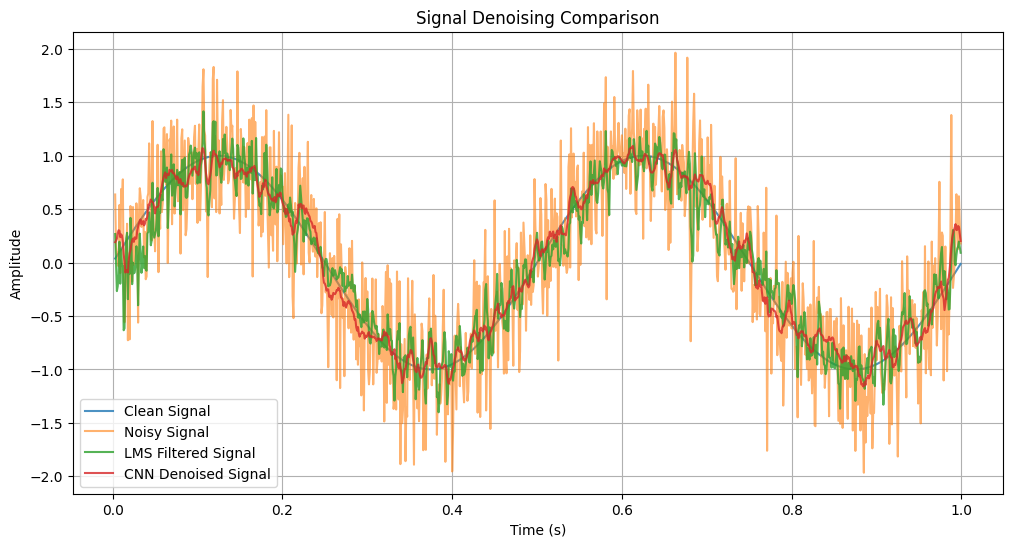

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(t_plot, aligned_clean, label='Clean Signal', alpha=0.8)
plt.plot(t_plot, aligned_noisy, label='Noisy Signal', alpha=0.6)
plt.plot(t_plot, y, label='LMS Filtered Signal', alpha=0.8)
plt.plot(t_plot, aligned_cnn_denoised, label='CNN Denoised Signal', alpha=0.8)
plt.title('Signal Denoising Comparison')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()


## Generating Diverse Dataset

In [9]:
from scipy.signal import chirp

def generate_sine(freq, fs, duration):
  t = np.linspace(0, duration, int(fs*duration), endpoint=False)
  return np.sin(2 * np.pi * freq * t)

def generate_multi_tone(freqs, fs, duration):
  t_gen = np.linspace(0, duration, int(fs*duration), endpoint=False)
  signal = np.sum([np.sin(2 * np.pi * f * t_gen) for f in freqs], axis=0)
  return signal, t_gen

def generate_chirp(f0, f1, duration, fs):
    t = np.linspace(0, duration, int(fs * duration), endpoint=False)
    return chirp(t, f0=f0, f1=f1, t1=duration, method='linear')

def generate_speech_like_signal(fs, duration, base_freq=100, amp_mod_freq=5, num_harmonics=3):
    t = np.linspace(0, duration, int(fs * duration), endpoint=False)
    signal = np.zeros_like(t)
    for i in range(1, num_harmonics + 1):
        # Simple amplitude modulation to mimic vocalization
        amplitude = (1.0 / i) * np.sin(2 * np.pi * amp_mod_freq * t + np.random.rand() * 2 * np.pi)
        signal += amplitude * np.sin(2 * np.pi * (base_freq * i) * t + np.random.rand() * 2 * np.pi)
    signal = signal / np.max(np.abs(signal))
    return signal

# --- Noise Addition Functions ---

def add_awgn(signal, snr_db):
  snr = 10 ** (snr_db / 10)
  signal_power = np.mean(signal ** 2)
  noise_power = signal_power / snr
  noise = np.random.normal(0, np.sqrt(noise_power), signal.shape)
  return signal + noise, noise

def add_colored_noise(signal, snr_db, fs, alpha=1): # alpha=0 for white, 1 for pink, 2 for brownian
    # Generate white noise
    white_noise = np.random.normal(0, 1, signal.shape)

    # Apply coloring (simple approximation using FFT)
    N = len(signal)
    fft_white = np.fft.fft(white_noise)
    frequencies = np.fft.fftfreq(N, 1/fs)
    frequencies[0] = 1e-10 # Avoids division by zero

    # 1/f^alpha weighting to magnitude spectrum
    # For alpha=1 (pink noise), magnitude should be proportional to 1/f^(alpha/2)
    # Phase remains the same as white noise for simplicity
    colored_noise_fft = fft_white / (np.abs(frequencies)**(alpha/2))
    colored_noise = np.fft.ifft(colored_noise_fft).real

    # Scales noise to achieve desired SNR
    snr = 10 ** (snr_db / 10)
    signal_power = np.mean(signal**2)
    noise_power_target = signal_power / snr
    colored_noise = colored_noise * np.sqrt(noise_power_target / np.mean(colored_noise**2))

    return signal + colored_noise, colored_noise

def add_impulse_noise(signal, impulse_prob, impulse_amplitude):
    noisy_signal = np.copy(signal)
    num_samples = len(signal)
    num_impulses = int(num_samples * impulse_prob)
    impulse_indices = np.random.choice(num_samples, num_impulses, replace=False)
    for idx in impulse_indices:
        noisy_signal[idx] += np.random.uniform(-impulse_amplitude, impulse_amplitude)
    return noisy_signal, noisy_signal - signal # Return signal and the actual noise added


In [10]:
# Parameters for dataset generation
fs_data = 1000
duration_data = 1 # seconds for each sample
num_samples_per_type = 100 # Number of samples for each signal/noise combination

all_clean_signals = []
all_noisy_signals = []

# --- Generate Sine Wave Data ---
for _ in range(num_samples_per_type):
    freq = np.random.uniform(1, 100) # Random frequency
    snr_db = np.random.uniform(0, 10) # Random SNR
    clean_s = generate_sine(freq, fs_data, duration_data)
    noisy_s, _ = add_awgn(clean_s, snr_db) # AWGN
    all_clean_signals.append(clean_s)
    all_noisy_signals.append(noisy_s)

# --- Generate Multi-Tone Data (AWGN) ---
for _ in range(num_samples_per_type):
    freqs = [np.random.uniform(1, 50), np.random.uniform(51, 100)] # Two random frequencies
    snr_db = np.random.uniform(0, 10)
    clean_mt, _ = generate_multi_tone(freqs, fs_data, duration_data)
    noisy_mt, _ = add_awgn(clean_mt, snr_db)
    all_clean_signals.append(clean_mt)
    all_noisy_signals.append(noisy_mt)

# --- Generate Multi-Tone Data (Pink Noise) ---
for _ in range(num_samples_per_type):
    freqs = [np.random.uniform(1, 50), np.random.uniform(51, 100)]
    snr_db = np.random.uniform(0, 10)
    clean_mt, _ = generate_multi_tone(freqs, fs_data, duration_data)
    noisy_mt, _ = add_colored_noise(clean_mt, snr_db, fs_data, alpha=1) # Pink Noise
    all_clean_signals.append(clean_mt)
    all_noisy_signals.append(noisy_mt)

# --- Generate Chirp Data (AWGN) ---
for _ in range(num_samples_per_type):
    f0 = np.random.uniform(1, 20)
    f1 = np.random.uniform(50, 200)
    snr_db = np.random.uniform(0, 10)
    clean_c = generate_chirp(f0, f1, duration_data, fs_data)
    noisy_c, _ = add_awgn(clean_c, snr_db)
    all_clean_signals.append(clean_c)
    all_noisy_signals.append(noisy_c)

# --- Generate Chirp Data (Pink Noise) ---
for _ in range(num_samples_per_type):
    f0 = np.random.uniform(1, 20)
    f1 = np.random.uniform(50, 200)
    snr_db = np.random.uniform(0, 10)
    clean_c = generate_chirp(f0, f1, duration_data, fs_data)
    noisy_c, _ = add_colored_noise(clean_c, snr_db, fs_data, alpha=1) # Pink Noise
    all_clean_signals.append(clean_c)
    all_noisy_signals.append(noisy_c)

# --- Generate Speech-like Data (AWGN) ---
for _ in range(num_samples_per_type):
    base_freq = np.random.uniform(80, 250) # Human vocal range
    amp_mod_freq = np.random.uniform(1, 10)
    snr_db = np.random.uniform(0, 10)
    clean_sp = generate_speech_like_signal(fs_data, duration_data, base_freq, amp_mod_freq)
    noisy_sp, _ = add_awgn(clean_sp, snr_db)
    all_clean_signals.append(clean_sp)
    all_noisy_signals.append(noisy_sp)

# --- Generate Speech-like Data (Pink Noise) ---
for _ in range(num_samples_per_type):
    base_freq = np.random.uniform(80, 250)
    amp_mod_freq = np.random.uniform(1, 10)
    snr_db = np.random.uniform(0, 10)
    clean_sp = generate_speech_like_signal(fs_data, duration_data, base_freq, amp_mod_freq)
    noisy_sp, _ = add_colored_noise(clean_sp, snr_db, fs_data, alpha=1) # Pink Noise
    all_clean_signals.append(clean_sp)
    all_noisy_signals.append(noisy_sp)

# --- Generate Impulse Noise Data for Training (Sine Wave with Impulse Noise) ---
for _ in range(num_samples_per_type):
    f_sine_impulse = np.random.uniform(20, 80)
    impulse_probability = np.random.uniform(0.005, 0.02)
    impulse_amplitude = np.random.uniform(3, 7)

    clean_imp = generate_sine(f_sine_impulse, fs_data, duration_data)
    noisy_imp, _ = add_impulse_noise(clean_imp, impulse_probability, impulse_amplitude)
    all_clean_signals.append(clean_imp)
    all_noisy_signals.append(noisy_imp)

X_train_np = np.array(all_noisy_signals)
y_train_np = np.array(all_clean_signals)

X_train_tensor = torch.from_numpy(X_train_np).float().unsqueeze(1)
y_train_tensor = torch.from_numpy(y_train_np).float().unsqueeze(1)

print(f"Shape of X_train_tensor: {X_train_tensor.shape}")
print(f"Shape of y_train_tensor: {y_train_tensor.shape}")
print(f"Total number of training samples: {len(all_clean_signals)}")


Shape of X_train_tensor: torch.Size([800, 1, 1000])
Shape of y_train_tensor: torch.Size([800, 1, 1000])
Total number of training samples: 800


### Retraining CNN with Diverse Dataset

In [11]:
from torch.utils.data import TensorDataset, DataLoader

# Tensor dataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

# DataLoader
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

model = DenoiseCNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Model, criterion, and optimizer re-initialized for diverse dataset training.")

num_epochs_diverse = 100

print(f"Starting training for {num_epochs_diverse} epochs with a batch size of {batch_size}...")

for epoch in range(num_epochs_diverse):
    for batch_idx, (noisy_batch, clean_batch) in enumerate(train_loader):
        # Forward pass
        outputs = model(noisy_batch)
        loss = criterion(outputs, clean_batch)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs_diverse}], Loss: {loss.item():.4f}')

print("CNN training complete")

Model, criterion, and optimizer re-initialized for diverse dataset training.
Starting training for 100 epochs with a batch size of 32...
Epoch [10/100], Loss: 0.1001
Epoch [20/100], Loss: 0.0738
Epoch [30/100], Loss: 0.0746
Epoch [40/100], Loss: 0.0873
Epoch [50/100], Loss: 0.0750
Epoch [60/100], Loss: 0.0645
Epoch [70/100], Loss: 0.0775
Epoch [80/100], Loss: 0.0587
Epoch [90/100], Loss: 0.0618
Epoch [100/100], Loss: 0.0481
CNN training complete


## Generating Diverse Test Data

In [12]:
fs_test = 1000 # Sampling frequency for test data
duration_test = 1 # seconds for each test sample
num_samples_per_type_test = 20 # Number of samples for each signal/noise combination in the test set

all_clean_test_signals = []
all_noisy_test_signals = []
all_signal_types_test = [] # To store signal type for each sample

# --- Generate Sine Wave Data for Test (AWGN) ---
for _ in range(num_samples_per_type_test):
    freq = np.random.uniform(1, 100) # Random frequency
    snr_db = np.random.uniform(0, 10) # Random SNR
    clean_s = generate_sine(freq, fs_test, duration_test)
    noisy_s, _ = add_awgn(clean_s, snr_db) # AWGN
    all_clean_test_signals.append(clean_s)
    all_noisy_test_signals.append(noisy_s)
    all_signal_types_test.append('Sine Wave (AWGN)')

# --- Generate Multi-Tone Data for Test (AWGN) ---
for _ in range(num_samples_per_type_test):
    freqs = [np.random.uniform(1, 50), np.random.uniform(51, 100)] # Two random frequencies
    snr_db = np.random.uniform(0, 10)
    clean_mt, _ = generate_multi_tone(freqs, fs_test, duration_test)
    noisy_mt, _ = add_awgn(clean_mt, snr_db)
    all_clean_test_signals.append(clean_mt)
    all_noisy_test_signals.append(noisy_mt)
    all_signal_types_test.append('Multi-tone (AWGN)')

# --- Generate Multi-Tone Data for Test (Pink Noise) ---
for _ in range(num_samples_per_type_test):
    freqs = [np.random.uniform(1, 50), np.random.uniform(51, 100)]
    snr_db = np.random.uniform(0, 10)
    clean_mt, _ = generate_multi_tone(freqs, fs_test, duration_test)
    noisy_mt, _ = add_colored_noise(clean_mt, snr_db, fs_test, alpha=1) # Pink Noise
    all_clean_test_signals.append(clean_mt)
    all_noisy_test_signals.append(noisy_mt)
    all_signal_types_test.append('Multi-tone (Pink Noise)')

# --- Generate Chirp Data for Test (AWGN) ---
for _ in range(num_samples_per_type_test):
    f0 = np.random.uniform(1, 20)
    f1 = np.random.uniform(50, 200)
    snr_db = np.random.uniform(0, 10)
    clean_c = generate_chirp(f0, f1, duration_test, fs_test)
    noisy_c, _ = add_awgn(clean_c, snr_db)
    all_clean_test_signals.append(clean_c)
    all_noisy_test_signals.append(noisy_c)
    all_signal_types_test.append('Chirp (AWGN)')

# --- Generate Chirp Data for Test (Pink Noise) ---
for _ in range(num_samples_per_type_test):
    f0 = np.random.uniform(1, 20)
    f1 = np.random.uniform(50, 200)
    snr_db = np.random.uniform(0, 10)
    clean_c = generate_chirp(f0, f1, duration_test, fs_test)
    noisy_c, _ = add_colored_noise(clean_c, snr_db, fs_test, alpha=1) # Pink Noise
    all_clean_test_signals.append(clean_c)
    all_noisy_test_signals.append(noisy_c)
    all_signal_types_test.append('Chirp (Pink Noise)')

# --- Generate Speech-like Data for Test (AWGN) ---
for _ in range(num_samples_per_type_test):
    base_freq = np.random.uniform(80, 250) # Human vocal range
    amp_mod_freq = np.random.uniform(1, 10)
    snr_db = np.random.uniform(0, 10)
    clean_sp = generate_speech_like_signal(fs_test, duration_test, base_freq, amp_mod_freq)
    noisy_sp, _ = add_awgn(clean_sp, snr_db)
    all_clean_test_signals.append(clean_sp)
    all_noisy_test_signals.append(noisy_sp)
    all_signal_types_test.append('Speech-like (AWGN)')

# --- Generate Speech-like Data for Test (Pink Noise) ---
for _ in range(num_samples_per_type_test):
    base_freq = np.random.uniform(80, 250)
    amp_mod_freq = np.random.uniform(1, 10)
    snr_db = np.random.uniform(0, 10)
    clean_sp = generate_speech_like_signal(fs_test, duration_test, base_freq, amp_mod_freq)
    noisy_sp, _ = add_colored_noise(clean_sp, snr_db, fs_test, alpha=1) # Pink Noise
    all_clean_test_signals.append(clean_sp)
    all_noisy_test_signals.append(noisy_sp)
    all_signal_types_test.append('Speech-like (Pink Noise)')

# --- Generate Impulse Noise Data for Test (Sine Wave with Impulse Noise) ---
def add_impulse_noise(signal, impulse_prob, impulse_amplitude):
    noisy_signal = np.copy(signal)
    num_samples = len(signal)
    num_impulses = int(num_samples * impulse_prob)
    impulse_indices = np.random.choice(num_samples, num_impulses, replace=False)
    for idx in impulse_indices:
        noisy_signal[idx] += np.random.uniform(-impulse_amplitude, impulse_amplitude)
    return noisy_signal

for _ in range(num_samples_per_type_test):
    f_sine_impulse = np.random.uniform(20, 80) # Random sine wave frequency
    impulse_probability = np.random.uniform(0.005, 0.02) # Random impulse probability
    impulse_amplitude = np.random.uniform(3, 7) # Random impulse amplitude

    clean_imp = generate_sine(f_sine_impulse, fs_test, duration_test)
    noisy_imp = add_impulse_noise(clean_imp, impulse_probability, impulse_amplitude)
    all_clean_test_signals.append(clean_imp)
    all_noisy_test_signals.append(noisy_imp)
    all_signal_types_test.append('Impulse Noise (Sine)')

# Convert lists to NumPy arrays
X_test_np = np.array(all_noisy_test_signals)
y_test_np = np.array(all_clean_test_signals)
signal_types_test_np = np.array(all_signal_types_test)

# Convert NumPy arrays to PyTorch tensors and reshape for CNN input (batch, channels, length)
X_test_tensor = torch.from_numpy(X_test_np).float().unsqueeze(1)
y_test_tensor = torch.from_numpy(y_test_np).float().unsqueeze(1)

print(f"Shape of X_test_tensor: {X_test_tensor.shape}")
print(f"Shape of y_test_tensor: {y_test_tensor.shape}")
print(f"Number of test samples: {len(signal_types_test_np)}")
print(f"Unique signal types in test set: {np.unique(signal_types_test_np)}")

Shape of X_test_tensor: torch.Size([160, 1, 1000])
Shape of y_test_tensor: torch.Size([160, 1, 1000])
Number of test samples: 160
Unique signal types in test set: ['Chirp (AWGN)' 'Chirp (Pink Noise)' 'Impulse Noise (Sine)'
 'Multi-tone (AWGN)' 'Multi-tone (Pink Noise)' 'Sine Wave (AWGN)'
 'Speech-like (AWGN)' 'Speech-like (Pink Noise)']


## Evaluating Retrained CNN on Diverse Test Data

In [13]:
model.eval()

all_snr_noisy = []
all_snr_denoised = []
all_snr_improvement = []

with torch.no_grad():
    for i in range(len(X_test_tensor)):
        noisy_sample_tensor = X_test_tensor[i].unsqueeze(0)
        clean_sample = y_test_np[i]

        # Denoise the sample
        denoised_sample_tensor = model(noisy_sample_tensor)
        denoised_sample = denoised_sample_tensor.squeeze().numpy()

        # Calculate SNRs
        snr_noisy = calculate_snr(clean_sample, noisy_sample_tensor.squeeze().numpy())
        snr_denoised = calculate_snr(clean_sample, denoised_sample)
        snr_improvement = snr_denoised - snr_noisy

        all_snr_noisy.append(snr_noisy)
        all_snr_denoised.append(snr_denoised)
        all_snr_improvement.append(snr_improvement)

print(f"Average SNR of original noisy signals: {np.mean(all_snr_noisy):.2f} dB")
print(f"Average SNR of CNN denoised signals: {np.mean(all_snr_denoised):.2f} dB")
print(f"Average SNR Improvement (CNN): {np.mean(all_snr_improvement):.2f} dB")

print("\nIndividual Sample Results:")
for i in range(min(5, len(all_snr_noisy))):
    print(f"Sample {i+1}: Noisy SNR={all_snr_noisy[i]:.2f} dB, Denoised SNR={all_snr_denoised[i]:.2f} dB, Improvement={all_snr_improvement[i]:.2f} dB")

Average SNR of original noisy signals: 5.25 dB
Average SNR of CNN denoised signals: 10.33 dB
Average SNR Improvement (CNN): 5.08 dB

Individual Sample Results:
Sample 1: Noisy SNR=5.57 dB, Denoised SNR=10.51 dB, Improvement=4.94 dB
Sample 2: Noisy SNR=7.03 dB, Denoised SNR=10.44 dB, Improvement=3.41 dB
Sample 3: Noisy SNR=3.38 dB, Denoised SNR=8.81 dB, Improvement=5.44 dB
Sample 4: Noisy SNR=4.77 dB, Denoised SNR=10.23 dB, Improvement=5.47 dB
Sample 5: Noisy SNR=4.70 dB, Denoised SNR=10.55 dB, Improvement=5.85 dB


### Visualizing Denoising Performance on Test Samples

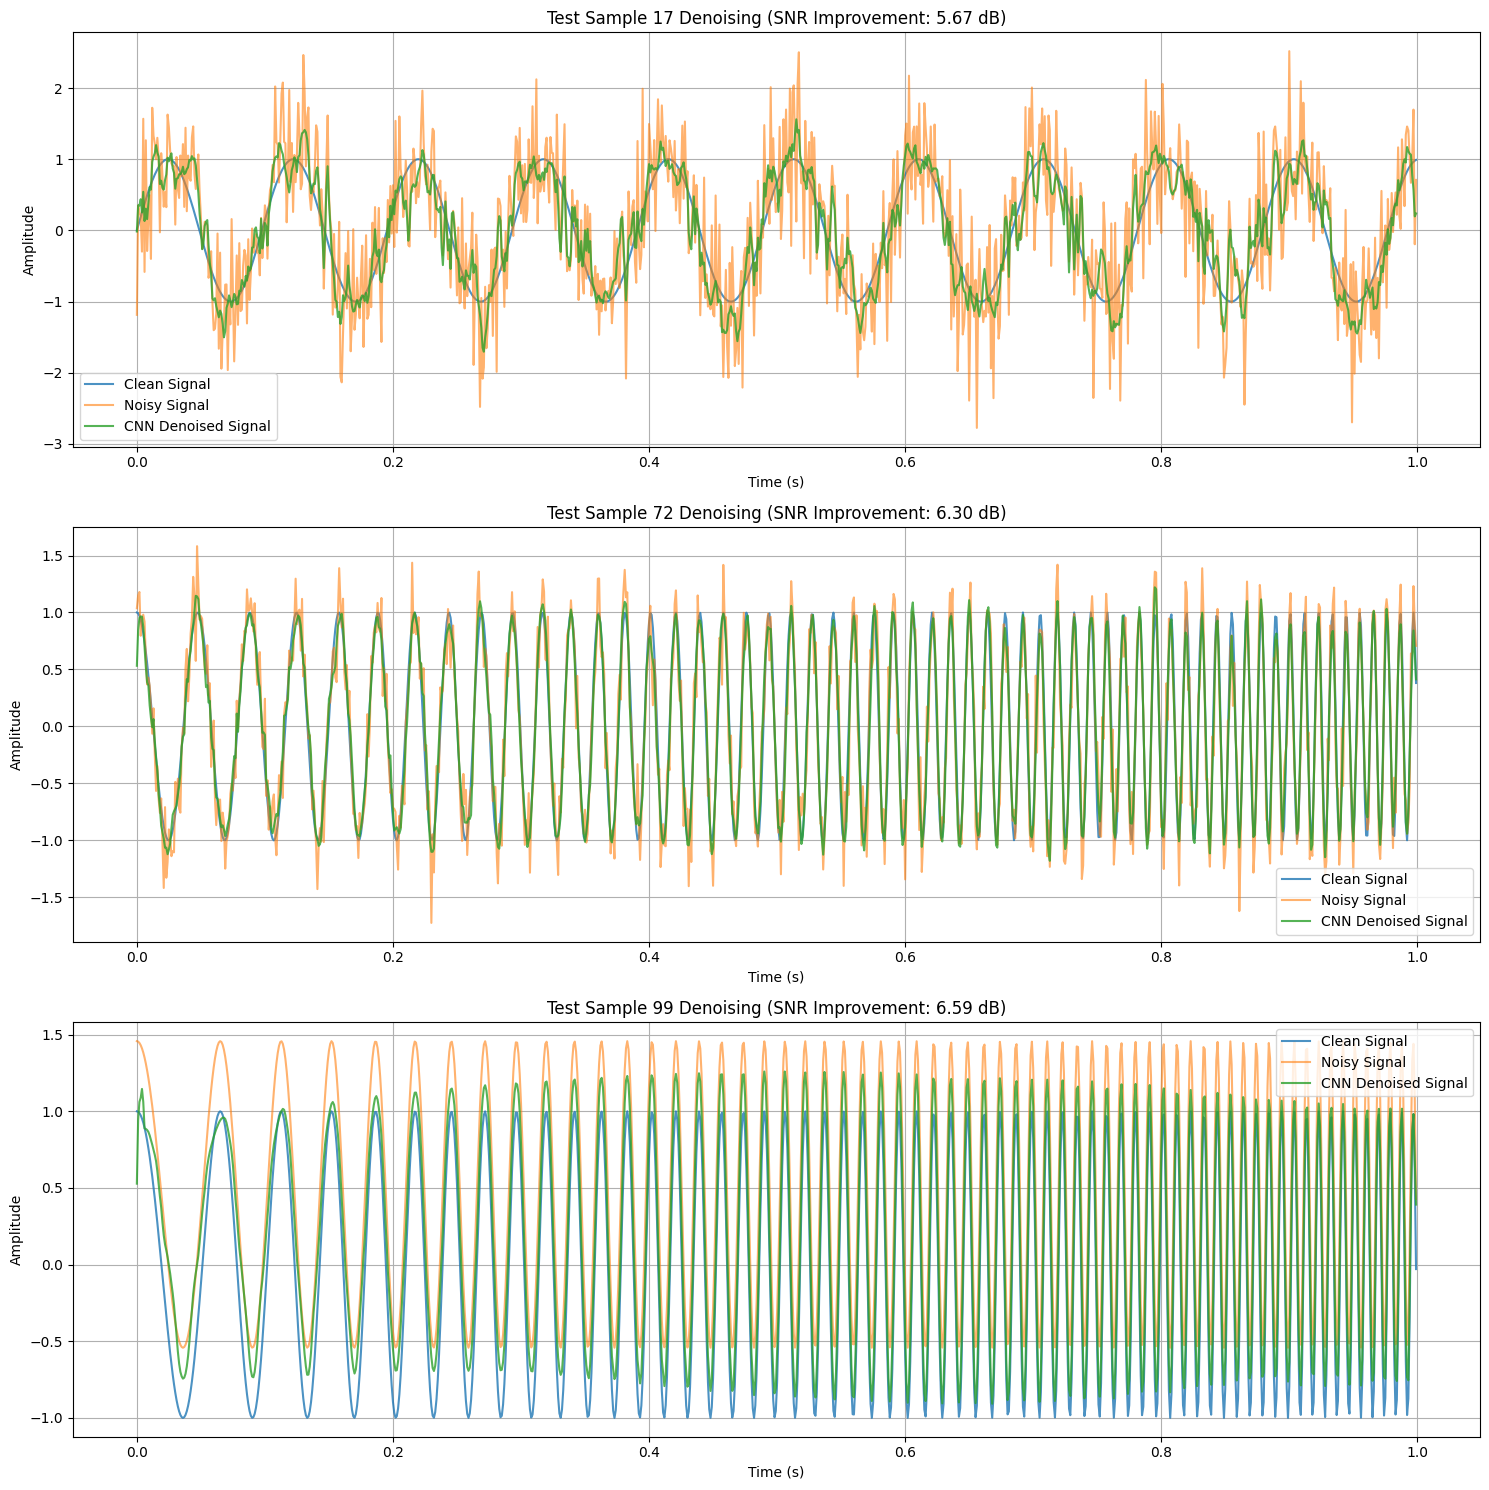

In [14]:
# Select a few random samples to plot
num_plots = 3
random_indices = np.random.choice(len(X_test_tensor), num_plots, replace=False)

plt.figure(figsize=(15, 5 * num_plots))

for i, idx in enumerate(random_indices):
    clean_sample = y_test_np[idx]
    noisy_sample = X_test_tensor[idx].squeeze().numpy()

    model.eval()
    with torch.no_grad():
        denoised_sample = model(X_test_tensor[idx].unsqueeze(0)).squeeze().numpy()

    # Generate time vector for plotting
    t_plot_test = np.linspace(0, duration_test, len(clean_sample), endpoint=False)

    plt.subplot(num_plots, 1, i + 1)
    plt.plot(t_plot_test, clean_sample, label='Clean Signal', alpha=0.8)
    plt.plot(t_plot_test, noisy_sample, label='Noisy Signal', alpha=0.6)
    plt.plot(t_plot_test, denoised_sample, label='CNN Denoised Signal', alpha=0.8)
    plt.title(f'Test Sample {idx+1} Denoising (SNR Improvement: {all_snr_improvement[idx]:.2f} dB)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

## Hyperparameter Tuning for CNN

In [15]:
num_samples_per_type_val = 10 # Number of samples for each signal/noise combination in the validation set

all_clean_val_signals = []
all_noisy_val_signals = []

# --- Generate Sine Wave Data for Validation (AWGN) ---
for _ in range(num_samples_per_type_val):
    freq = np.random.uniform(1, 100) # Random frequency
    snr_db = np.random.uniform(0, 10) # Random SNR
    clean_s = generate_sine(freq, fs_data, duration_data)
    noisy_s, _ = add_awgn(clean_s, snr_db) # AWGN
    all_clean_val_signals.append(clean_s)
    all_noisy_val_signals.append(noisy_s)

# --- Generate Multi-Tone Data for Validation (AWGN) ---
for _ in range(num_samples_per_type_val):
    freqs = [np.random.uniform(1, 50), np.random.uniform(51, 100)] # Two random frequencies
    snr_db = np.random.uniform(0, 10)
    clean_mt, _ = generate_multi_tone(freqs, fs_data, duration_data)
    noisy_mt, _ = add_awgn(clean_mt, snr_db)
    all_clean_val_signals.append(clean_mt)
    all_noisy_val_signals.append(noisy_mt)

# --- Generate Multi-Tone Data for Validation (Pink Noise) ---
for _ in range(num_samples_per_type_val):
    freqs = [np.random.uniform(1, 50), np.random.uniform(51, 100)]
    snr_db = np.random.uniform(0, 10)
    clean_mt, _ = generate_multi_tone(freqs, fs_data, duration_data)
    noisy_mt, _ = add_colored_noise(clean_mt, snr_db, fs_data, alpha=1) # Pink Noise
    all_clean_val_signals.append(clean_mt)
    all_noisy_val_signals.append(noisy_mt)

# --- Generate Chirp Data for Validation (AWGN) ---
for _ in range(num_samples_per_type_val):
    f0 = np.random.uniform(1, 20)
    f1 = np.random.uniform(50, 200)
    snr_db = np.random.uniform(0, 10)
    clean_c = generate_chirp(f0, f1, duration_data, fs_data)
    noisy_c, _ = add_awgn(clean_c, snr_db)
    all_clean_val_signals.append(clean_c)
    all_noisy_val_signals.append(noisy_c)

# --- Generate Chirp Data for Validation (Pink Noise) ---
for _ in range(num_samples_per_type_val):
    f0 = np.random.uniform(1, 20)
    f1 = np.random.uniform(50, 200)
    snr_db = np.random.uniform(0, 10)
    clean_c = generate_chirp(f0, f1, duration_data, fs_data)
    noisy_c, _ = add_colored_noise(clean_c, snr_db, fs_data, alpha=1) # Pink Noise
    all_clean_val_signals.append(clean_c)
    all_noisy_val_signals.append(noisy_c)

# --- Generate Speech-like Data for Validation (AWGN) ---
for _ in range(num_samples_per_type_val):
    base_freq = np.random.uniform(80, 250) # Human vocal range
    amp_mod_freq = np.random.uniform(1, 10)
    snr_db = np.random.uniform(0, 10)
    clean_sp = generate_speech_like_signal(fs_data, duration_data, base_freq, amp_mod_freq)
    noisy_sp, _ = add_awgn(clean_sp, snr_db)
    all_clean_val_signals.append(clean_sp)
    all_noisy_val_signals.append(noisy_sp)

# --- Generate Speech-like Data for Validation (Pink Noise) ---
for _ in range(num_samples_per_type_val):
    base_freq = np.random.uniform(80, 250)
    amp_mod_freq = np.random.uniform(1, 10)
    snr_db = np.random.uniform(0, 10)
    clean_sp = generate_speech_like_signal(fs_data, duration_data, base_freq, amp_mod_freq)
    noisy_sp, _ = add_colored_noise(clean_sp, snr_db, fs_data, alpha=1) # Pink Noise
    all_clean_val_signals.append(clean_sp)
    all_noisy_val_signals.append(noisy_sp)

X_val_np = np.array(all_noisy_val_signals)
y_val_np = np.array(all_clean_val_signals)

X_val_tensor = torch.from_numpy(X_val_np).float().unsqueeze(1)
y_val_tensor = torch.from_numpy(y_val_np).float().unsqueeze(1)

print(f"Shape of X_val_tensor: {X_val_tensor.shape}")
print(f"Shape of y_val_tensor: {y_val_tensor.shape}")

Shape of X_val_tensor: torch.Size([70, 1, 1000])
Shape of y_val_tensor: torch.Size([70, 1, 1000])


In [16]:
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Hyperparameter search space
learning_rates = [0.01, 0.001, 0.0001]
batch_sizes = [16, 32, 64]
num_epochs_tuning = 50

best_snr_improvement = -float('inf')
best_hyperparams = {}
best_model_state = None

tuning_results = [] # To store results for all configurations

print("Starting hyperparameter tuning")

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"\n--- Testing LR: {lr}, Batch Size: {bs} ---")

        current_model = DenoiseCNN()
        current_criterion = nn.MSELoss()
        current_optimizer = torch.optim.Adam(current_model.parameters(), lr=lr)

        train_loader_tuning = DataLoader(train_dataset, batch_size=bs, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False)

        # Training loop
        for epoch in range(num_epochs_tuning):
            current_model.train()
            for batch_idx, (noisy_batch, clean_batch) in enumerate(train_loader_tuning):
                # Forward pass
                outputs = current_model(noisy_batch)
                loss = current_criterion(outputs, clean_batch)

                # Backward and optimize
                current_optimizer.zero_grad()
                loss.backward()
                current_optimizer.step()

            # Training loss for every few epochs
            if (epoch+1) % 10 == 0:
                print(f'  Epoch [{epoch+1}/{num_epochs_tuning}], Loss: {loss.item():.4f}')

        # Evaluation on validation set
        current_model.eval()
        all_snr_noisy_val = []
        all_snr_denoised_val = []
        all_snr_improvement_val = []

        with torch.no_grad():
            for i in range(len(X_val_tensor)):
                noisy_sample_tensor_val = X_val_tensor[i].unsqueeze(0)
                clean_sample_val = y_val_np[i]

                # Denoise the sample
                denoised_sample_tensor_val = current_model(noisy_sample_tensor_val)
                denoised_sample_val = denoised_sample_tensor_val.squeeze().numpy()

                # Calculate SNRs
                snr_noisy_val = calculate_snr(clean_sample_val, noisy_sample_tensor_val.squeeze().numpy())
                snr_denoised_val = calculate_snr(clean_sample_val, denoised_sample_val)
                snr_improvement_val = snr_denoised_val - snr_noisy_val

                all_snr_noisy_val.append(snr_noisy_val)
                all_snr_denoised_val.append(snr_denoised_val)
                all_snr_improvement_val.append(snr_improvement_val)

        avg_snr_improvement_val = np.mean(all_snr_improvement_val)
        print(f"  Average SNR Improvement on Validation Set: {avg_snr_improvement_val:.2f} dB")
        tuning_results.append({'lr': lr, 'batch_size': bs, 'avg_snr_improvement': avg_snr_improvement_val})

        if avg_snr_improvement_val > best_snr_improvement:
            best_snr_improvement = avg_snr_improvement_val
            best_hyperparams = {'learning_rate': lr, 'batch_size': bs}
            best_model_state = current_model.state_dict()

print("\nHyperparameter tuning complete.")
print(f"Best Hyperparameters: {best_hyperparams}")
print(f"Best Average SNR Improvement on Validation Set: {best_snr_improvement:.2f} dB")
model.load_state_dict(best_model_state)
print("Best model state loaded into the main 'model' instance.")


Starting hyperparameter tuning

--- Testing LR: 0.01, Batch Size: 16 ---
  Epoch [10/50], Loss: 0.0691
  Epoch [20/50], Loss: 0.0708
  Epoch [30/50], Loss: 0.0689
  Epoch [40/50], Loss: 0.0762
  Epoch [50/50], Loss: 0.0582
  Average SNR Improvement on Validation Set: 4.70 dB

--- Testing LR: 0.01, Batch Size: 32 ---
  Epoch [10/50], Loss: 0.0678
  Epoch [20/50], Loss: 0.0681
  Epoch [30/50], Loss: 0.0677
  Epoch [40/50], Loss: 0.0679
  Epoch [50/50], Loss: 0.0536
  Average SNR Improvement on Validation Set: 4.85 dB

--- Testing LR: 0.01, Batch Size: 64 ---
  Epoch [10/50], Loss: 0.0733
  Epoch [20/50], Loss: 0.0647
  Epoch [30/50], Loss: 0.0671
  Epoch [40/50], Loss: 0.0703
  Epoch [50/50], Loss: 0.0558
  Average SNR Improvement on Validation Set: 4.71 dB

--- Testing LR: 0.001, Batch Size: 16 ---
  Epoch [10/50], Loss: 0.0775
  Epoch [20/50], Loss: 0.0634
  Epoch [30/50], Loss: 0.0679
  Epoch [40/50], Loss: 0.0706
  Epoch [50/50], Loss: 0.0992
  Average SNR Improvement on Validation S

In [17]:
# Put the best model (after tuning) in evaluation mode
model.eval()

all_snr_noisy_final_test = []
all_snr_denoised_final_test = []
all_snr_improvement_final_test = []

with torch.no_grad():
    for i in range(len(X_test_tensor)):
        noisy_sample_tensor = X_test_tensor[i].unsqueeze(0)
        clean_sample = y_test_np[i]
        denoised_sample_tensor = model(noisy_sample_tensor)
        denoised_sample = denoised_sample_tensor.squeeze().numpy()

        # Calculate SNRs
        snr_noisy = calculate_snr(clean_sample, noisy_sample_tensor.squeeze().numpy())
        snr_denoised = calculate_snr(clean_sample, denoised_sample)
        snr_improvement = snr_denoised - snr_noisy

        all_snr_noisy_final_test.append(snr_noisy)
        all_snr_denoised_final_test.append(snr_denoised)
        all_snr_improvement_final_test.append(snr_improvement)

print(f"\n--- Final Evaluation on Test Set with Tuned Hyperparameters ---")
print(f"Average SNR of original noisy signals (Test Set): {np.mean(all_snr_noisy_final_test):.2f} dB")
print(f"Average SNR of CNN denoised signals (Test Set): {np.mean(all_snr_denoised_final_test):.2f} dB")
print(f"Average SNR Improvement (CNN, Test Set): {np.mean(all_snr_improvement_final_test):.2f} dB")
print("\nIndividual Test Sample Results (Tuned Model):")
for i in range(min(5, len(all_snr_noisy_final_test))):
    print(f"Sample {i+1}: Noisy SNR={all_snr_noisy_final_test[i]:.2f} dB, Denoised SNR={all_snr_denoised_final_test[i]:.2f} dB, Improvement={all_snr_improvement_final_test[i]:.2f} dB")


--- Final Evaluation on Test Set with Tuned Hyperparameters ---
Average SNR of original noisy signals (Test Set): 5.25 dB
Average SNR of CNN denoised signals (Test Set): 10.64 dB
Average SNR Improvement (CNN, Test Set): 5.39 dB

Individual Test Sample Results (Tuned Model):
Sample 1: Noisy SNR=5.57 dB, Denoised SNR=10.33 dB, Improvement=4.76 dB
Sample 2: Noisy SNR=7.03 dB, Denoised SNR=10.44 dB, Improvement=3.41 dB
Sample 3: Noisy SNR=3.38 dB, Denoised SNR=8.54 dB, Improvement=5.16 dB
Sample 4: Noisy SNR=4.77 dB, Denoised SNR=10.29 dB, Improvement=5.52 dB
Sample 5: Noisy SNR=4.70 dB, Denoised SNR=10.35 dB, Improvement=5.65 dB


### RMSE for LMS vs CNN Across the Test Set

In [18]:
def calculate_rmse(original_signal, processed_signal):
    original_signal = np.asarray(original_signal)
    processed_signal = np.asarray(processed_signal)

    error = original_signal - processed_signal
    mse = np.mean(error**2)
    rmse = np.sqrt(mse)
    return rmse

In [19]:
all_rmse_lms = []
all_rmse_cnn = []
n_taps = 4
model.eval()

with torch.no_grad():
    for i in range(len(X_test_tensor)):
        clean_sample = y_test_np[i]
        noisy_sample = X_test_np[i]

        # --- CNN Denoising ---
        noisy_sample_tensor = torch.from_numpy(noisy_sample).float().unsqueeze(0).unsqueeze(0)
        cnn_denoised_tensor = model(noisy_sample_tensor)
        cnn_denoised_signal = cnn_denoised_tensor.squeeze().numpy()

        # --- LMS Denoising ---
        lms_filter_current = pa.filters.FilterLMS(n=n_taps, mu=0.1, w="random")
        x_input_matrix_lms = pa.input_from_history(noisy_sample, n_taps)
        d_filtered_lms = clean_sample[n_taps-1:]
        y_lms, _, _ = lms_filter_current.run(d_filtered_lms, x_input_matrix_lms)

        # Align signals for RMSE calculation (to match LMS output length)
        aligned_clean_sample = clean_sample[n_taps-1:]
        aligned_cnn_denoised_sample = cnn_denoised_signal[n_taps-1:]

        # Calculate RMSE
        rmse_lms = calculate_rmse(aligned_clean_sample, y_lms)
        rmse_cnn = calculate_rmse(aligned_clean_sample, aligned_cnn_denoised_sample)

        all_rmse_lms.append(rmse_lms)
        all_rmse_cnn.append(rmse_cnn)

print(f"Calculated RMSE for {len(all_rmse_lms)} LMS samples and {len(all_rmse_cnn)} CNN samples.")
print(f"Average RMSE (LMS): {np.mean(all_rmse_lms):.4f}")
print(f"Average RMSE (CNN): {np.mean(all_rmse_cnn):.4f}")

Calculated RMSE for 160 LMS samples and 160 CNN samples.
Average RMSE (LMS): 0.3427
Average RMSE (CNN): 0.2263


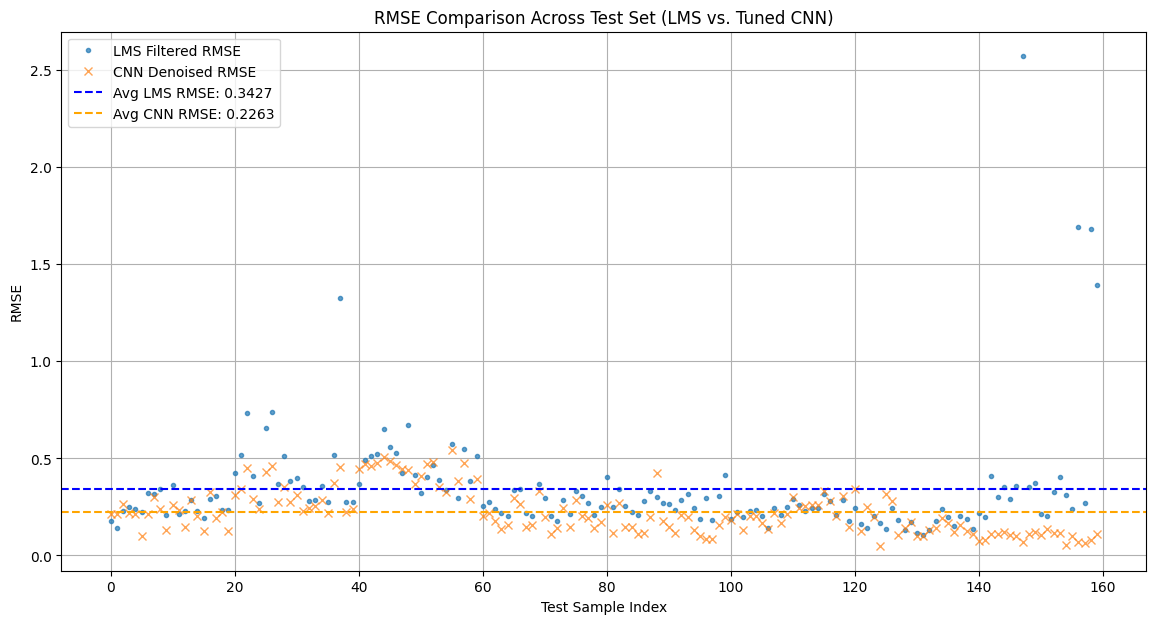

In [20]:
plt.figure(figsize=(14, 7))
plt.plot(all_rmse_lms, label='LMS Filtered RMSE', marker='.', linestyle='None', alpha=0.7)
plt.plot(all_rmse_cnn, label='CNN Denoised RMSE', marker='x', linestyle='None', alpha=0.7)

plt.axhline(np.mean(all_rmse_lms), color='blue', linestyle='--', label=f'Avg LMS RMSE: {np.mean(all_rmse_lms):.4f}')
plt.axhline(np.mean(all_rmse_cnn), color='orange', linestyle='--', label=f'Avg CNN RMSE: {np.mean(all_rmse_cnn):.4f}')

plt.title('RMSE Comparison Across Test Set (LMS vs. Tuned CNN)')
plt.xlabel('Test Sample Index')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.show()

### Quantization/Pruning for CNN

In [21]:
import torch.quantization
import torch.nn.utils.prune
import os

# Helper function to calculate model size
def print_model_size(model, label=""):
    torch.save(model.state_dict(), "temp_model.p")
    size_mb = os.path.getsize("temp_model.p") / 1e6
    print(f"{label} Model size: {size_mb:.2f} MB")
    os.remove("temp_model.p")
    return size_mb

In [22]:
# This version includes placeholders for quantization operations
class QuantizedDenoiseCNN(nn.Module):
    def __init__(self, model_fp32):
        super(QuantizedDenoiseCNN, self).__init__()
        # QuantStub converts float to quantized tensor
        self.quant = torch.quantization.QuantStub()
        # DeQuantStub converts quantized tensor to float
        self.dequant = torch.quantization.DeQuantStub()
        self.model_fp32 = model_fp32 # original float32 model

        # This is where fusing layers would typically happen, but for a simple Sequential model,
        # torch.quantization.prepare_qat will just do some basic fusion.

    def forward(self, x):
        x = self.quant(x)
        x = self.model_fp32(x)
        x = self.dequant(x)
        return x

In [23]:
print("Starting post-training static quantization")

# 1. Create a copy of the best trained float32 model
model_fp32_base = DenoiseCNN()
model_fp32_base.load_state_dict(best_model_state)
model_fp32_base.eval()
size_fp32 = print_model_size(model_fp32_base, "Original FP32")

# 2. Create the QuantizedDenoiseCNN wrapper
model_to_quantize = QuantizedDenoiseCNN(model_fp32_base)
model_to_quantize.eval()

# 3. Fuse modules within the wrapped model's internal float32 model
torch.quantization.fuse_modules(model_to_quantize.model_fp32.net, [['0', '1'], ['2', '3']], inplace=True)

# 4. Specify quantization configuration for the wrapped model
model_to_quantize.qconfig = torch.quantization.get_default_qconfig('fbgemm') # Recommended for server CPUs

# 5. Prepare the model for static quantization
model_prepared = torch.quantization.prepare(model_to_quantize)

# 6. Calibrate the model with a representative dataset
print("calibrating quantized model")
model_prepared.eval()
with torch.no_grad():
    for i, (noisy_batch, _) in enumerate(train_loader):
        if i >= 5:
            break
        model_prepared(noisy_batch)

# 7. Convert the model to a quantized version
model_quantized = torch.quantization.convert(model_prepared)
model_quantized.eval()

print("Post-training static quantization complete")
size_quantized = print_model_size(model_quantized, "Quantized INT8")
print(f"Size reduction: {((size_fp32 - size_quantized) / size_fp32) * 100:.2f}%")

Starting post-training static quantization
Original FP32 Model size: 0.01 MB
calibrating quantized model


/tmp/ipykernel_2524/2856367991.py:20: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_prepared = torch.quantization.prepare(model_to_quantize)
/usr/local/lib/python3.12/dist-packages/torch/ao/quantization/observer.py:1039: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a futur

Post-training static quantization complete
Quantized INT8 Model size: 0.01 MB
Size reduction: 25.59%


/tmp/ipykernel_2524/2856367991.py:32: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_quantized = torch.quantization.convert(model_prepared)


In [24]:
print("Evaluating Quantized CNN on Test Set")

all_snr_noisy_q = []
all_snr_denoised_q = []
all_snr_improvement_q = []

with torch.no_grad():
    for i in range(len(X_test_tensor)):
        noisy_sample_tensor = X_test_tensor[i].unsqueeze(0)
        clean_sample = y_test_np[i]

        denoised_sample_tensor = model_quantized(noisy_sample_tensor)
        denoised_sample = denoised_sample_tensor.squeeze().numpy()

        # Calculate SNRs
        snr_noisy = calculate_snr(clean_sample, noisy_sample_tensor.squeeze().numpy())
        snr_denoised = calculate_snr(clean_sample, denoised_sample)
        snr_improvement = snr_denoised - snr_noisy

        all_snr_noisy_q.append(snr_noisy)
        all_snr_denoised_q.append(snr_denoised)
        all_snr_improvement_q.append(snr_improvement)

# Calculate and print average SNR improvements on the final test set
print(f"Average SNR of original noisy signals (Quantized Test Set): {np.mean(all_snr_noisy_q):.2f} dB")
print(f"Average SNR of Quantized CNN denoised signals (Test Set): {np.mean(all_snr_denoised_q):.2f} dB")
print(f"Average SNR Improvement (Quantized CNN, Test Set): {np.mean(all_snr_improvement_q):.2f} dB")

# Compare with original tuned CNN performance
print(f"Original Tuned CNN Average SNR Improvement: {np.mean(all_snr_improvement_final_test):.2f} dB")
print(f"Difference in SNR Improvement: {np.mean(all_snr_improvement_final_test) - np.mean(all_snr_improvement_q):.2f} dB")

Evaluating Quantized CNN on Test Set
Average SNR of original noisy signals (Quantized Test Set): 5.25 dB
Average SNR of Quantized CNN denoised signals (Test Set): 10.50 dB
Average SNR Improvement (Quantized CNN, Test Set): 5.25 dB
Original Tuned CNN Average SNR Improvement: 5.39 dB
Difference in SNR Improvement: 0.14 dB


## Applying Pruning to the CNN Model

In [25]:
import torch.nn.utils.prune as prune

model_for_pruning = DenoiseCNN()
model_for_pruning.load_state_dict(best_model_state)
model_for_pruning.eval()

print("Original model size before pruning:")
print_model_size(model_for_pruning, "")

# Pruning 50% of the connections in the convolutional layers
parameters_to_prune = [
    (model_for_pruning.net[0], 'weight'),
    (model_for_pruning.net[2], 'weight')
]

# Global unstructured pruning
prune.global_unstructured(parameters_to_prune, pruning_method=prune.L1Unstructured, amount=0.5)

print("\nPruning applied. Now removing permanent pruning re-parametrization")

for module, name in parameters_to_prune:
    prune.remove(module, name)

print("Pruning complete")

# Print pruned model size
size_pruned = print_model_size(model_for_pruning, "Pruned FP32")

# Evaluate the pruned model on the test set
print("\nEvaluating Pruned CNN")

all_snr_noisy_p = []
all_snr_denoised_p = []
all_snr_improvement_p = []

with torch.no_grad():
    for i in range(len(X_test_tensor)):
        noisy_sample_tensor = X_test_tensor[i].unsqueeze(0) # Add batch dimension
        clean_sample = y_test_np[i]

        # Denoise the sample using the pruned model
        denoised_sample_tensor = model_for_pruning(noisy_sample_tensor)
        denoised_sample = denoised_sample_tensor.squeeze().numpy() # Remove batch and channel dims

        # Calculate SNRs
        snr_noisy = calculate_snr(clean_sample, noisy_sample_tensor.squeeze().numpy())
        snr_denoised = calculate_snr(clean_sample, denoised_sample)
        snr_improvement = snr_denoised - snr_noisy

        all_snr_noisy_p.append(snr_noisy)
        all_snr_denoised_p.append(snr_denoised)
        all_snr_improvement_p.append(snr_improvement)

# Calculate and print average SNR improvements on the final test set
print(f"Average SNR of original noisy signals (Pruned Test Set): {np.mean(all_snr_noisy_p):.2f} dB")
print(f"Average SNR of Pruned CNN denoised signals (Test Set): {np.mean(all_snr_denoised_p):.2f} dB")
print(f"Average SNR Improvement (Pruned CNN, Test Set): {np.mean(all_snr_improvement_p):.2f} dB")

# Compare with original tuned CNN performance
print(f"Original Tuned CNN Average SNR Improvement: {np.mean(all_snr_improvement_final_test):.2f} dB")
print(f"Difference in SNR Improvement: {np.mean(all_snr_improvement_final_test) - np.mean(all_snr_improvement_p):.2f} dB")



Original model size before pruning:
 Model size: 0.01 MB

Pruning applied. Now removing permanent pruning re-parametrization
Pruning complete
Pruned FP32 Model size: 0.01 MB

Evaluating Pruned CNN
Average SNR of original noisy signals (Pruned Test Set): 5.25 dB
Average SNR of Pruned CNN denoised signals (Test Set): 8.03 dB
Average SNR Improvement (Pruned CNN, Test Set): 2.78 dB
Original Tuned CNN Average SNR Improvement: 5.39 dB
Difference in SNR Improvement: 2.61 dB


### Denoising Autoencoder

In [26]:
class DenoiseDAE(nn.Module):
    def __init__(self):
        super(DenoiseDAE, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2, stride=2),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=5, padding=2, stride=2),
            nn.ReLU(),
            nn.Conv1d(128, 256, kernel_size=5, padding=2, stride=2),
            nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(256, 128, kernel_size=5, padding=2, stride=2, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(128, 64, kernel_size=5, padding=2, stride=2, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(64, 32, kernel_size=5, padding=2, stride=2, output_padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 1, kernel_size=5, padding=2),
            nn.Tanh()
        )

    def forward(self, x):
        # Encoder path
        encoded = self.encoder(x)

        # Decoder path
        decoded = self.decoder(encoded)
        return x + decoded

### Training DenoiseDAE with Diverse Dataset and Evaluating

In [27]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset_dae = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset_dae = TensorDataset(X_val_tensor, y_val_tensor)

batch_size = 16
train_loader_dae = DataLoader(train_dataset_dae, batch_size=batch_size, shuffle=True)
val_loader_dae = DataLoader(val_dataset_dae, batch_size=batch_size, shuffle=False)

model_dae = DenoiseDAE()
criterion_dae = nn.MSELoss()
optimizer_dae = torch.optim.Adam(model_dae.parameters(), lr=0.001)

print("DenoiseDAE model initialized")

num_epochs_dae = 100

best_val_loss = float('inf')
best_dae_model_state = None

print(f"Starting DAE training for {num_epochs_dae} epochs with a batch size of {batch_size}")

for epoch in range(num_epochs_dae):
    model_dae.train()
    for batch_idx, (noisy_batch, clean_batch) in enumerate(train_loader_dae):
        # Forward pass
        outputs = model_dae(noisy_batch)
        loss = criterion_dae(outputs, clean_batch)

        # Backward and optimize
        optimizer_dae.zero_grad()
        loss.backward()
        optimizer_dae.step()

    # Evaluate on validation set after each epoch
    model_dae.eval()
    val_loss = 0.0
    with torch.no_grad():
        for noisy_val_batch, clean_val_batch in val_loader_dae:
            val_outputs = model_dae(noisy_val_batch)
            val_loss += criterion_dae(val_outputs, clean_val_batch).item()
    val_loss /= len(val_loader_dae)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_dae_model_state = model_dae.state_dict()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs_dae}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss:.4f}')

print("DAE training complete")
if best_dae_model_state is not None:
    model_dae.load_state_dict(best_dae_model_state)
    print("Best DAE model state loaded")
else:
    print("no best DAE model state saved (maybe training was too short?)")

DenoiseDAE model initialized
Starting DAE training for 100 epochs with a batch size of 16
Epoch [10/100], Train Loss: 0.0389, Val Loss: 0.0461
Epoch [20/100], Train Loss: 0.0433, Val Loss: 0.0348
Epoch [30/100], Train Loss: 0.0299, Val Loss: 0.0311
Epoch [40/100], Train Loss: 0.0202, Val Loss: 0.0293
Epoch [50/100], Train Loss: 0.0306, Val Loss: 0.0271
Epoch [60/100], Train Loss: 0.0247, Val Loss: 0.0278
Epoch [70/100], Train Loss: 0.0230, Val Loss: 0.0269
Epoch [80/100], Train Loss: 0.0149, Val Loss: 0.0273
Epoch [90/100], Train Loss: 0.0191, Val Loss: 0.0274
Epoch [100/100], Train Loss: 0.0064, Val Loss: 0.0272
DAE training complete
Best DAE model state loaded


### Evaluating DenoiseDAE on Validation Set

In [29]:
model_dae.eval()

all_snr_noisy_dae_val = []
all_snr_denoised_dae_val = []
all_snr_improvement_dae_val = []

with torch.no_grad():
    for i in range(len(X_val_tensor)):
        noisy_sample_tensor_val = X_val_tensor[i].unsqueeze(0)
        clean_sample_val = y_val_np[i]

        # Denoise the sample
        denoised_sample_tensor_val = model_dae(noisy_sample_tensor_val)
        denoised_sample_val = denoised_sample_tensor_val.squeeze().numpy()

        # Calculate SNRs
        snr_noisy_val = calculate_snr(clean_sample_val, noisy_sample_tensor_val.squeeze().numpy())
        snr_denoised_val = calculate_snr(clean_sample_val, denoised_sample_val)
        snr_improvement_val = snr_denoised_val - snr_noisy_val

        all_snr_noisy_dae_val.append(snr_noisy_val)
        all_snr_denoised_dae_val.append(snr_denoised_val)
        all_snr_improvement_dae_val.append(snr_improvement_val)

print(f"\n--- DenoiseDAE Evaluation on Validation Set ---")
print(f"Average SNR of original noisy signals (Validation Set): {np.mean(all_snr_noisy_dae_val):.2f} dB")
print(f"Average SNR of DenoiseDAE denoised signals (Validation Set): {np.mean(all_snr_denoised_dae_val):.2f} dB")
print(f"Average SNR Improvement (DenoiseDAE, Validation Set): {np.mean(all_snr_improvement_dae_val):.2f} dB")

print("\nIndividual Validation Sample Results (DAE Model):")
for i in range(min(5, len(all_snr_noisy_dae_val))):
    print(f"Sample {i+1}: Noisy SNR={all_snr_noisy_dae_val[i]:.2f} dB, Denoised SNR={all_snr_denoised_dae_val[i]:.2f} dB, Improvement={all_snr_improvement_dae_val[i]:.2f} dB")


--- DenoiseDAE Evaluation on Validation Set ---
Average SNR of original noisy signals (Validation Set): 4.83 dB
Average SNR of DenoiseDAE denoised signals (Validation Set): 18.04 dB
Average SNR Improvement (DenoiseDAE, Validation Set): 13.21 dB

Individual Validation Sample Results (DAE Model):
Sample 1: Noisy SNR=4.79 dB, Denoised SNR=15.20 dB, Improvement=10.41 dB
Sample 2: Noisy SNR=9.70 dB, Denoised SNR=20.88 dB, Improvement=11.18 dB
Sample 3: Noisy SNR=8.33 dB, Denoised SNR=18.66 dB, Improvement=10.33 dB
Sample 4: Noisy SNR=0.66 dB, Denoised SNR=8.40 dB, Improvement=7.74 dB
Sample 5: Noisy SNR=3.56 dB, Denoised SNR=13.31 dB, Improvement=9.75 dB


### Hyperparameter Tuning for DenoiseDAE

In [35]:
from torch.utils.data import TensorDataset, DataLoader

learning_rates = [0.01, 0.001, 0.0001] # shorted to save time, but tested with 0.01, 0.001, 0.0001
batch_sizes = [16, 32, 64] # shortened to save time, but tested with 16, 32, 64
num_epochs_tuning = 50

best_snr_improvement_dae_tuning = -float('inf')
best_hyperparams_dae = {}
best_dae_model_state_tuning = None

dae_tuning_results = [] # List to store DAE tuning results

print("Starting DAE hyperparameter tuning")

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"\n--- Testing LR: {lr}, Batch Size: {bs} ---")

        current_dae_model = DenoiseDAE()
        current_criterion_dae = nn.MSELoss()
        current_optimizer_dae = torch.optim.Adam(current_dae_model.parameters(), lr=lr)
        train_loader_tuning_dae = DataLoader(train_dataset_dae, batch_size=bs, shuffle=True)
        val_loader_tuning_dae = DataLoader(val_dataset_dae, batch_size=bs, shuffle=False)

        for epoch in range(num_epochs_tuning):
            current_dae_model.train()
            for batch_idx, (noisy_batch, clean_batch) in enumerate(train_loader_tuning_dae):
                # Forward pass
                outputs = current_dae_model(noisy_batch)
                loss = current_criterion_dae(outputs, clean_batch)

                # Backward and optimize
                current_optimizer_dae.zero_grad()
                loss.backward()
                current_optimizer_dae.step()

            if (epoch+1) % 10 == 0:
                print(f'  Epoch [{epoch+1}/{num_epochs_tuning}], Train Loss: {loss.item():.4f}')

        current_dae_model.eval()
        all_snr_noisy_val_tuning = []
        all_snr_denoised_val_tuning = []
        all_snr_improvement_val_tuning = []

        with torch.no_grad():
            for i in range(len(X_val_tensor)):
                noisy_sample_tensor_val = X_val_tensor[i].unsqueeze(0)
                clean_sample_val = y_val_np[i]

                denoised_sample_tensor_val = current_dae_model(noisy_sample_tensor_val)
                denoised_sample_val = denoised_sample_tensor_val.squeeze().numpy()

                snr_noisy_val = calculate_snr(clean_sample_val, noisy_sample_tensor_val.squeeze().numpy())
                snr_denoised_val = calculate_snr(clean_sample_val, denoised_sample_val)
                snr_improvement_val = snr_denoised_val - snr_noisy_val

                all_snr_noisy_val_tuning.append(snr_noisy_val)
                all_snr_denoised_val_tuning.append(snr_denoised_val)
                all_snr_improvement_val_tuning.append(snr_improvement_val)

        avg_snr_improvement_val = np.mean(all_snr_improvement_val_tuning)
        print(f"  Average SNR Improvement on Validation Set: {avg_snr_improvement_val:.2f} dB")
        dae_tuning_results.append({'lr': lr, 'batch_size': bs, 'avg_snr_improvement': avg_snr_improvement_val}) # Store results

        if avg_snr_improvement_val > best_snr_improvement_dae_tuning:
            best_snr_improvement_dae_tuning = avg_snr_improvement_val
            best_hyperparams_dae = {'learning_rate': lr, 'batch_size': bs}
            best_dae_model_state_tuning = current_dae_model.state_dict()

print("\nDAE Hyperparameter tuning complete.")
print(f"Best Hyperparameters for DAE: {best_hyperparams_dae}")
print(f"Best Average SNR Improvement on Validation Set: {best_snr_improvement_dae_tuning:.2f} dB")

# Load the best model state into the existing model_dae instance
if best_dae_model_state_tuning is not None:
    model_dae.load_state_dict(best_dae_model_state_tuning)
    print("Best DAE model state loaded into the main 'model_dae' instance.")
else:
    print("No best DAE model state was found or saved during tuning.")

Starting DAE hyperparameter tuning

--- Testing LR: 0.01, Batch Size: 16 ---
  Epoch [10/50], Train Loss: 0.1390
  Epoch [20/50], Train Loss: 0.0686
  Epoch [30/50], Train Loss: 0.1078
  Epoch [40/50], Train Loss: 0.0263
  Epoch [50/50], Train Loss: 0.0541
  Average SNR Improvement on Validation Set: 4.74 dB

--- Testing LR: 0.01, Batch Size: 32 ---
  Epoch [10/50], Train Loss: 0.1025
  Epoch [20/50], Train Loss: 0.0938
  Epoch [30/50], Train Loss: 0.0916
  Epoch [40/50], Train Loss: 0.0675
  Epoch [50/50], Train Loss: 0.0293
  Average SNR Improvement on Validation Set: 7.70 dB

--- Testing LR: 0.01, Batch Size: 64 ---
  Epoch [10/50], Train Loss: 0.1402
  Epoch [20/50], Train Loss: 0.1352
  Epoch [30/50], Train Loss: 0.1282
  Epoch [40/50], Train Loss: 0.1447
  Epoch [50/50], Train Loss: 0.1296
  Average SNR Improvement on Validation Set: 6.02 dB

--- Testing LR: 0.001, Batch Size: 16 ---
  Epoch [10/50], Train Loss: 0.0318
  Epoch [20/50], Train Loss: 0.0532
  Epoch [30/50], Train Lo

### Evaluating DenoiseDAE on Test Data

In [37]:
model_dae.eval()

all_snr_noisy_dae_test = []
all_snr_denoised_dae_test = []
all_snr_improvement_dae_test = []

with torch.no_grad():
    for i in range(len(X_test_tensor)):
        noisy_sample_tensor = X_test_tensor[i].unsqueeze(0)
        clean_sample = y_test_np[i]

        denoised_sample_tensor = model_dae(noisy_sample_tensor)
        denoised_sample = denoised_sample_tensor.squeeze().numpy()

        snr_noisy = calculate_snr(clean_sample, noisy_sample_tensor.squeeze().numpy())
        snr_denoised = calculate_snr(clean_sample, denoised_sample)
        snr_improvement = snr_denoised - snr_noisy

        all_snr_noisy_dae_test.append(snr_noisy)
        all_snr_denoised_dae_test.append(snr_denoised)
        all_snr_improvement_dae_test.append(snr_improvement)

print(f"\n--- DenoiseDAE Evaluation on Test Set ---")
print(f"Average SNR of original noisy signals (DAE Test Set): {np.mean(all_snr_noisy_dae_test):.2f} dB")
print(f"Average SNR of DenoiseDAE denoised signals (DAE Test Set): {np.mean(all_snr_denoised_dae_test):.2f} dB")
print(f"Average SNR Improvement (DenoiseDAE, Test Set): {np.mean(all_snr_improvement_dae_test):.2f} dB")

# Compare with original tuned CNN performance
print(f"\nOriginal Tuned CNN Average SNR Improvement (Test Set): {np.mean(all_snr_improvement_final_test):.2f} dB")
print(f"Difference in SNR Improvement (DAE - Tuned CNN): {np.mean(all_snr_improvement_dae_test) - np.mean(all_snr_improvement_final_test):.2f} dB")


--- DenoiseDAE Evaluation on Test Set ---
Average SNR of original noisy signals (DAE Test Set): 5.25 dB
Average SNR of DenoiseDAE denoised signals (DAE Test Set): 16.25 dB
Average SNR Improvement (DenoiseDAE, Test Set): 11.00 dB

Original Tuned CNN Average SNR Improvement (Test Set): 5.39 dB
Difference in SNR Improvement (DAE - Tuned CNN): 5.61 dB



Calculated RMSE for 160 LMS samples and 160 DenoiseDAE samples.
Average RMSE (LMS): 0.3175 (excluding 2 largest outliers)
Average RMSE (DenoiseDAE): 0.1465


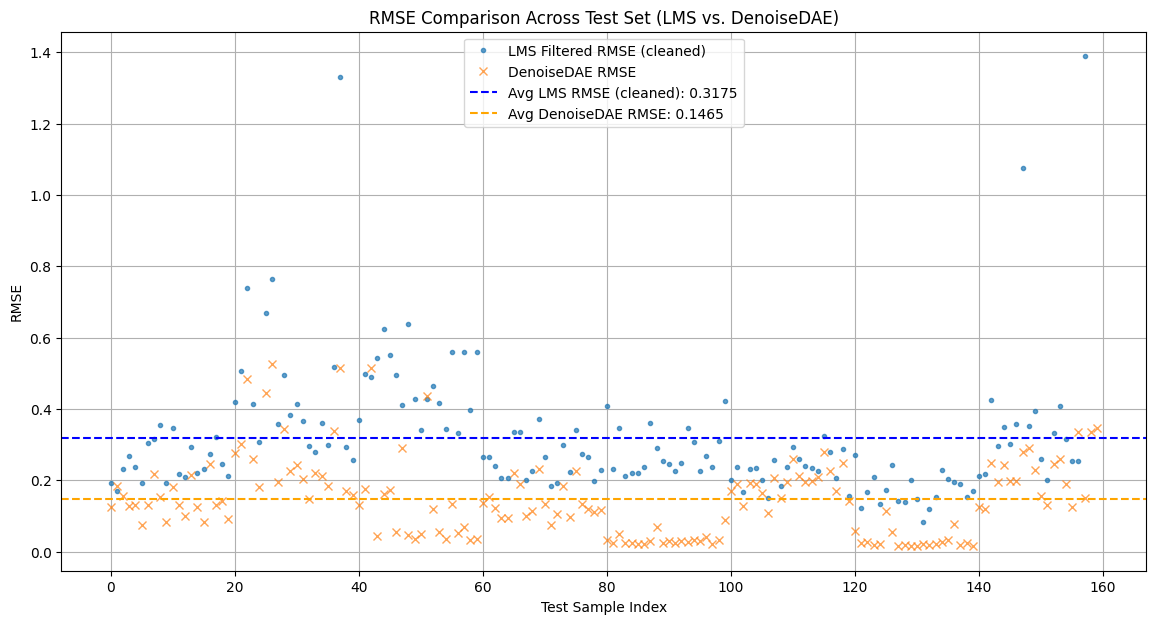

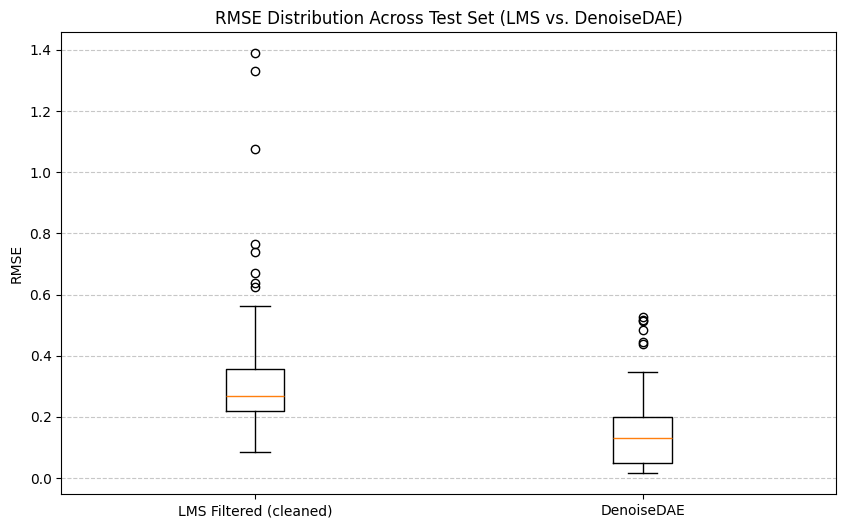

In [38]:
# --- RMSE Comparison Across the Test Set (LMS vs DenoiseDAE) ---

all_rmse_lms_dae_comparison = []
all_rmse_dae_comparison = []
n_taps = 4

model_dae.eval()

with torch.no_grad():
    for i in range(len(X_test_tensor)):
        clean_sample = y_test_np[i]
        noisy_sample = X_test_np[i]

        # --- DAE Denoising ---
        noisy_sample_tensor_dae = torch.from_numpy(noisy_sample).float().unsqueeze(0).unsqueeze(0)
        denoised_sample_tensor_dae = model_dae(noisy_sample_tensor_dae)
        denoised_sample_dae = denoised_sample_tensor_dae.squeeze().numpy()

        # --- LMS Denoising ---
        lms_filter_current = pa.filters.FilterLMS(n=n_taps, mu=0.1, w="random")
        x_input_matrix_lms = pa.input_from_history(noisy_sample, n_taps)

        d_for_lms_run = clean_sample[n_taps-1:]
        y_lms, _, _ = lms_filter_current.run(d_for_lms_run, x_input_matrix_lms)

        aligned_clean_sample = clean_sample[n_taps-1:]
        aligned_denoised_dae_sample = denoised_sample_dae[n_taps-1:]

        rmse_lms = calculate_rmse(aligned_clean_sample, y_lms)
        rmse_dae = calculate_rmse(aligned_clean_sample, aligned_denoised_dae_sample)

        all_rmse_lms_dae_comparison.append(rmse_lms)
        all_rmse_dae_comparison.append(rmse_dae)

np_rmse_lms = np.array(all_rmse_lms_dae_comparison)

# Remove the two largest outliers from LMS RMSE (messes up graphs)
if len(np_rmse_lms) > 2:
    largest_indices = np.argsort(np_rmse_lms)[-2:]
    mask = np.ones(len(np_rmse_lms), dtype=bool)
    mask[largest_indices] = False
    all_rmse_lms_dae_comparison_cleaned = np_rmse_lms[mask].tolist()
else:
    all_rmse_lms_dae_comparison_cleaned = all_rmse_lms_dae_comparison

print(f"\nCalculated RMSE for {len(all_rmse_lms_dae_comparison)} LMS samples and {len(all_rmse_dae_comparison)} DenoiseDAE samples.")
print(f"Average RMSE (LMS): {np.mean(all_rmse_lms_dae_comparison_cleaned):.4f} (excluding 2 largest outliers)")
print(f"Average RMSE (DenoiseDAE): {np.mean(all_rmse_dae_comparison):.4f}")

plt.figure(figsize=(14, 7))
plt.plot(all_rmse_lms_dae_comparison_cleaned, label='LMS Filtered RMSE (cleaned)', marker='.', linestyle='None', alpha=0.7)
plt.plot(all_rmse_dae_comparison, label='DenoiseDAE RMSE', marker='x', linestyle='None', alpha=0.7)

plt.axhline(np.mean(all_rmse_lms_dae_comparison_cleaned), color='blue', linestyle='--', label=f'Avg LMS RMSE (cleaned): {np.mean(all_rmse_lms_dae_comparison_cleaned):.4f}')
plt.axhline(np.mean(all_rmse_dae_comparison), color='orange', linestyle='--', label=f'Avg DenoiseDAE RMSE: {np.mean(all_rmse_dae_comparison):.4f}')

plt.title('RMSE Comparison Across Test Set (LMS vs. DenoiseDAE)')
plt.xlabel('Test Sample Index')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.boxplot([all_rmse_lms_dae_comparison_cleaned, all_rmse_dae_comparison], tick_labels=['LMS Filtered (cleaned)', 'DenoiseDAE'])
plt.title('RMSE Distribution Across Test Set (LMS vs. DenoiseDAE)')
plt.ylabel('RMSE')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Analysis by Signal Type

In [39]:
signal_type_data = {
    'Sine Wave (AWGN)': {'lms_rmse': [], 'dae_rmse': []},
    'Multi-tone (AWGN)': {'lms_rmse': [], 'dae_rmse': []},
    'Multi-tone (Pink Noise)': {'lms_rmse': [], 'dae_rmse': []},
    'Chirp (AWGN)': {'lms_rmse': [], 'dae_rmse': []},
    'Chirp (Pink Noise)': {'lms_rmse': [], 'dae_rmse': []},
    'Speech-like (AWGN)': {'lms_rmse': [], 'dae_rmse': []},
    'Speech-like (Pink Noise)': {'lms_rmse': [], 'dae_rmse': []},
    'Impulse Noise (Sine)': {'lms_rmse': [], 'dae_rmse': []}
}

n_taps = 4
model_dae.eval()
fs = 1000

with torch.no_grad():
    for i in range(len(X_test_tensor)):
        clean_sample = y_test_np[i]
        noisy_sample = X_test_np[i]

        current_signal_type = signal_types_test_np[i]

        # --- DAE Denoising ---
        noisy_sample_tensor_dae = torch.from_numpy(noisy_sample).float().unsqueeze(0).unsqueeze(0)
        denoised_sample_tensor_dae = model_dae(noisy_sample_tensor_dae)
        denoised_sample_dae = denoised_sample_tensor_dae.squeeze().numpy()

        # --- LMS Denoising ---
        lms_filter_current = pa.filters.FilterLMS(n=n_taps, mu=0.1, w="random")
        x_input_matrix_lms = pa.input_from_history(noisy_sample, n_taps)
        d_for_lms_run = clean_sample[n_taps-1:]
        y_lms, _, _ = lms_filter_current.run(d_for_lms_run, x_input_matrix_lms)

        aligned_clean_sample = clean_sample[n_taps-1:]
        aligned_denoised_dae_sample = denoised_sample_dae[n_taps-1:]
        rmse_lms = calculate_rmse(aligned_clean_sample, y_lms)
        rmse_dae = calculate_rmse(aligned_clean_sample, aligned_denoised_dae_sample)

        if current_signal_type not in signal_type_data:
            signal_type_data[current_signal_type] = {'lms_rmse': [], 'dae_rmse': []}
        signal_type_data[current_signal_type]['lms_rmse'].append(rmse_lms)
        signal_type_data[current_signal_type]['dae_rmse'].append(rmse_dae)

for s_type, data in signal_type_data.items():
    avg_lms_rmse = np.mean(data['lms_rmse']) if data['lms_rmse'] else np.nan
    avg_dae_rmse = np.mean(data['dae_rmse']) if data['dae_rmse'] else np.nan
    print(f"\nSignal Type: {s_type}")
    print(f"  Average LMS RMSE: {avg_lms_rmse:.4f}")
    print(f"  Average DAE RMSE: {avg_dae_rmse:.4f}")


Signal Type: Sine Wave (AWGN)
  Average LMS RMSE: 0.2550
  Average DAE RMSE: 0.1414

Signal Type: Multi-tone (AWGN)
  Average LMS RMSE: 0.4749
  Average DAE RMSE: 0.2817

Signal Type: Multi-tone (Pink Noise)
  Average LMS RMSE: 0.4641
  Average DAE RMSE: 0.1328

Signal Type: Chirp (AWGN)
  Average LMS RMSE: 0.2594
  Average DAE RMSE: 0.1380

Signal Type: Chirp (Pink Noise)
  Average LMS RMSE: 0.2811
  Average DAE RMSE: 0.0339

Signal Type: Speech-like (AWGN)
  Average LMS RMSE: 0.2244
  Average DAE RMSE: 0.1921

Signal Type: Speech-like (Pink Noise)
  Average LMS RMSE: 0.1682
  Average DAE RMSE: 0.0319

Signal Type: Impulse Noise (Sine)
  Average LMS RMSE: 0.5787
  Average DAE RMSE: 0.2204


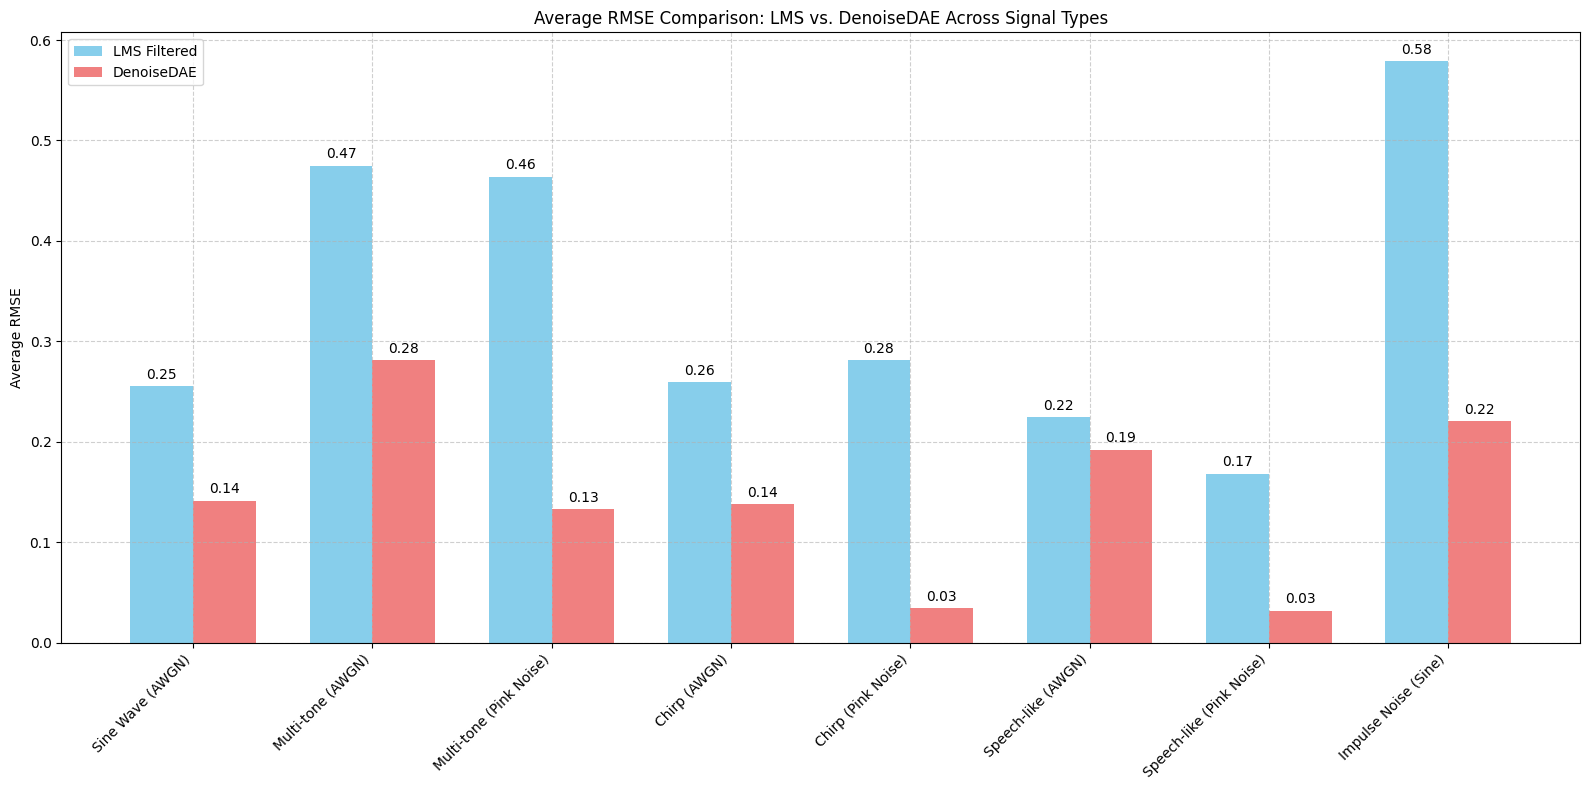

In [40]:
signal_types = list(signal_type_data.keys())
avg_lms_rmse_list = [np.mean(signal_type_data[s_type]['lms_rmse']) if signal_type_data[s_type]['lms_rmse'] else 0 for s_type in signal_types]
avg_dae_rmse_list = [np.mean(signal_type_data[s_type]['dae_rmse']) if signal_type_data[s_type]['dae_rmse'] else 0 for s_type in signal_types]

x = np.arange(len(signal_types))
width = 0.35
fig, ax = plt.subplots(figsize=(16, 8))
rects1 = ax.bar(x - width/2, avg_lms_rmse_list, width, label='LMS Filtered', color='skyblue')
rects2 = ax.bar(x + width/2, avg_dae_rmse_list, width, label='DenoiseDAE', color='lightcoral')

ax.set_ylabel('Average RMSE')
ax.set_title('Average RMSE Comparison: LMS vs. DenoiseDAE Across Signal Types')
ax.set_xticks(x)
ax.set_xticklabels(signal_types, rotation=45, ha="right")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()


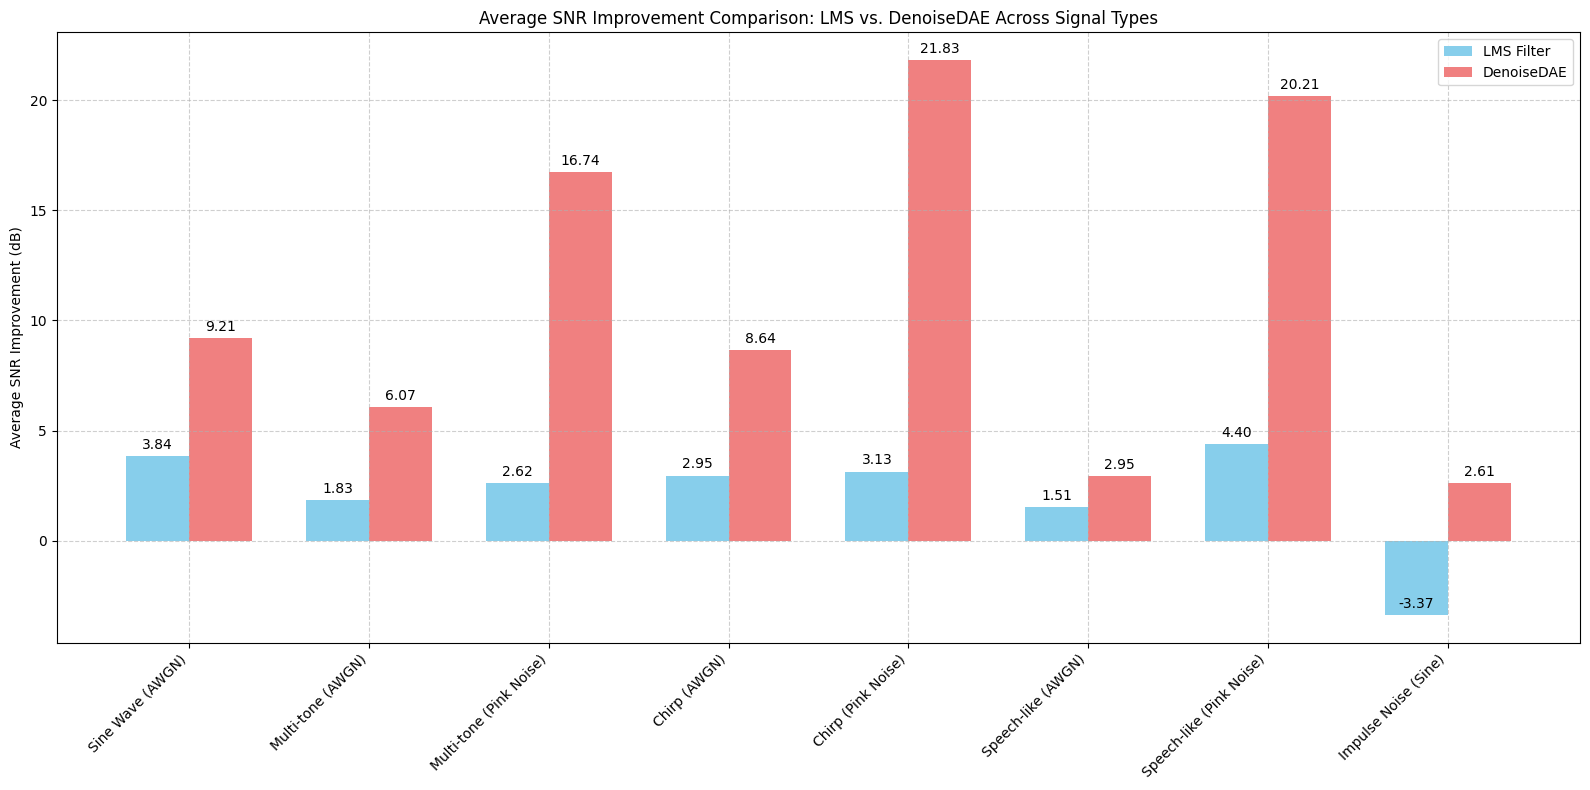

In [41]:
snr_improvement_data = {
    'Sine Wave (AWGN)': {'lms_snr_imp': [], 'dae_snr_imp': []},
    'Multi-tone (AWGN)': {'lms_snr_imp': [], 'dae_snr_imp': []},
    'Multi-tone (Pink Noise)': {'lms_snr_imp': [], 'dae_snr_imp': []},
    'Chirp (AWGN)': {'lms_snr_imp': [], 'dae_snr_imp': []},
    'Chirp (Pink Noise)': {'lms_snr_imp': [], 'dae_snr_imp': []},
    'Speech-like (AWGN)': {'lms_snr_imp': [], 'dae_snr_imp': []},
    'Speech-like (Pink Noise)': {'lms_snr_imp': [], 'dae_snr_imp': []},
    'Impulse Noise (Sine)': {'lms_snr_imp': [], 'dae_snr_imp': []}
}

model_dae.eval()
with torch.no_grad():
    for i in range(len(X_test_tensor)):
        clean_sample = y_test_np[i]
        noisy_sample = X_test_np[i]
        current_signal_type = signal_types_test_np[i]

        # --- DenoiseDAE Denoising ---
        noisy_sample_tensor_dae = torch.from_numpy(noisy_sample).float().unsqueeze(0).unsqueeze(0)
        denoised_sample_tensor_dae = model_dae(noisy_sample_tensor_dae)
        denoised_sample_dae = denoised_sample_tensor_dae.squeeze().numpy()

        # --- LMS Denoising ---
        lms_filter_current = pa.filters.FilterLMS(n=n_taps, mu=0.1, w="random")
        x_input_matrix_lms = pa.input_from_history(noisy_sample, n_taps)
        d_for_lms_run = clean_sample[n_taps-1:]
        y_lms, _, _ = lms_filter_current.run(d_for_lms_run, x_input_matrix_lms)

        aligned_clean_sample = clean_sample[n_taps-1:]
        aligned_noisy_sample = noisy_sample[n_taps-1:]
        aligned_denoised_dae_sample = denoised_sample_dae[n_taps-1:]

        snr_noisy_current = calculate_snr(aligned_clean_sample, aligned_noisy_sample)
        snr_lms_current = calculate_snr(aligned_clean_sample, y_lms)
        snr_dae_current = calculate_snr(aligned_clean_sample, aligned_denoised_dae_sample)
        snr_improvement_lms = snr_lms_current - snr_noisy_current
        snr_improvement_dae = snr_dae_current - snr_noisy_current

        if current_signal_type not in snr_improvement_data:
            snr_improvement_data[current_signal_type] = {'lms_snr_imp': [], 'dae_snr_imp': []}
        snr_improvement_data[current_signal_type]['lms_snr_imp'].append(snr_improvement_lms)
        snr_improvement_data[current_signal_type]['dae_snr_imp'].append(snr_improvement_dae)


signal_types = list(snr_improvement_data.keys())
avg_lms_snr_imp_list = [np.mean(snr_improvement_data[s_type]['lms_snr_imp']) if snr_improvement_data[s_type]['lms_snr_imp'] else 0 for s_type in signal_types]
avg_dae_snr_imp_list = [np.mean(snr_improvement_data[s_type]['dae_snr_imp']) if snr_improvement_data[s_type]['dae_snr_imp'] else 0 for s_type in signal_types]

x = np.arange(len(signal_types))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 8))
rects1 = ax.bar(x - width/2, avg_lms_snr_imp_list, width, label='LMS Filter', color='skyblue')
rects2 = ax.bar(x + width/2, avg_dae_snr_imp_list, width, label='DenoiseDAE', color='lightcoral')

ax.set_ylabel('Average SNR Improvement (dB)')
ax.set_title('Average SNR Improvement Comparison: LMS vs. DenoiseDAE Across Signal Types')
ax.set_xticks(x)
ax.set_xticklabels(signal_types, rotation=45, ha="right")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

### Overall Average SNR Improvement Comparison

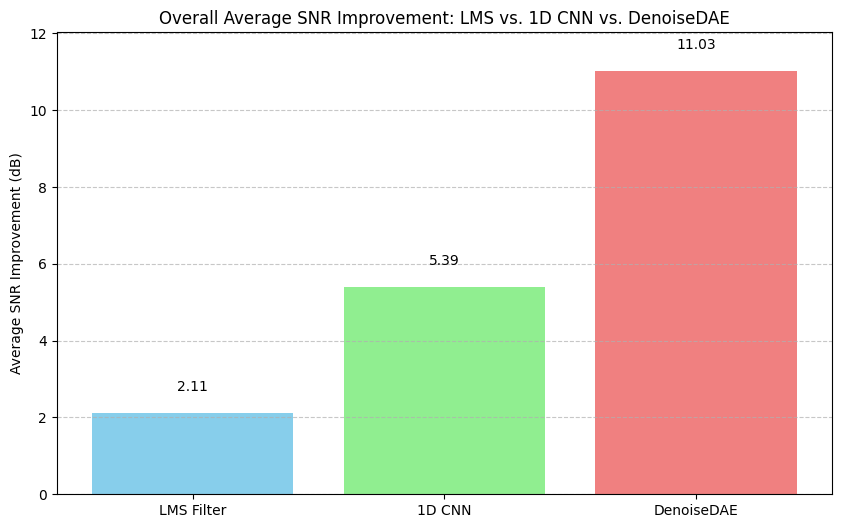

In [42]:
import matplotlib.pyplot as plt
import numpy as np

overall_avg_lms_snr_imp = np.mean(avg_lms_snr_imp_list)
overall_avg_cnn_snr_imp = np.mean(all_snr_improvement_final_test)
overall_avg_dae_snr_imp = np.mean(avg_dae_snr_imp_list)

model_names = ['LMS Filter', '1D CNN', 'DenoiseDAE']
snr_improvements = [overall_avg_lms_snr_imp, overall_avg_cnn_snr_imp, overall_avg_dae_snr_imp]

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, snr_improvements, color=['skyblue', 'lightgreen', 'lightcoral'])
plt.ylabel('Average SNR Improvement (dB)')
plt.title('Overall Average SNR Improvement: LMS vs. 1D CNN vs. DenoiseDAE')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.2f}', ha='center', va='bottom')

plt.ylim(min(0, min(snr_improvements) - 1), max(snr_improvements) + 1) # Adjust y-axis limit for better visualization
plt.show()

### Average SNR Improvement Comparison Across Signal Types (LMS vs. 1D CNN vs. DenoiseDAE)

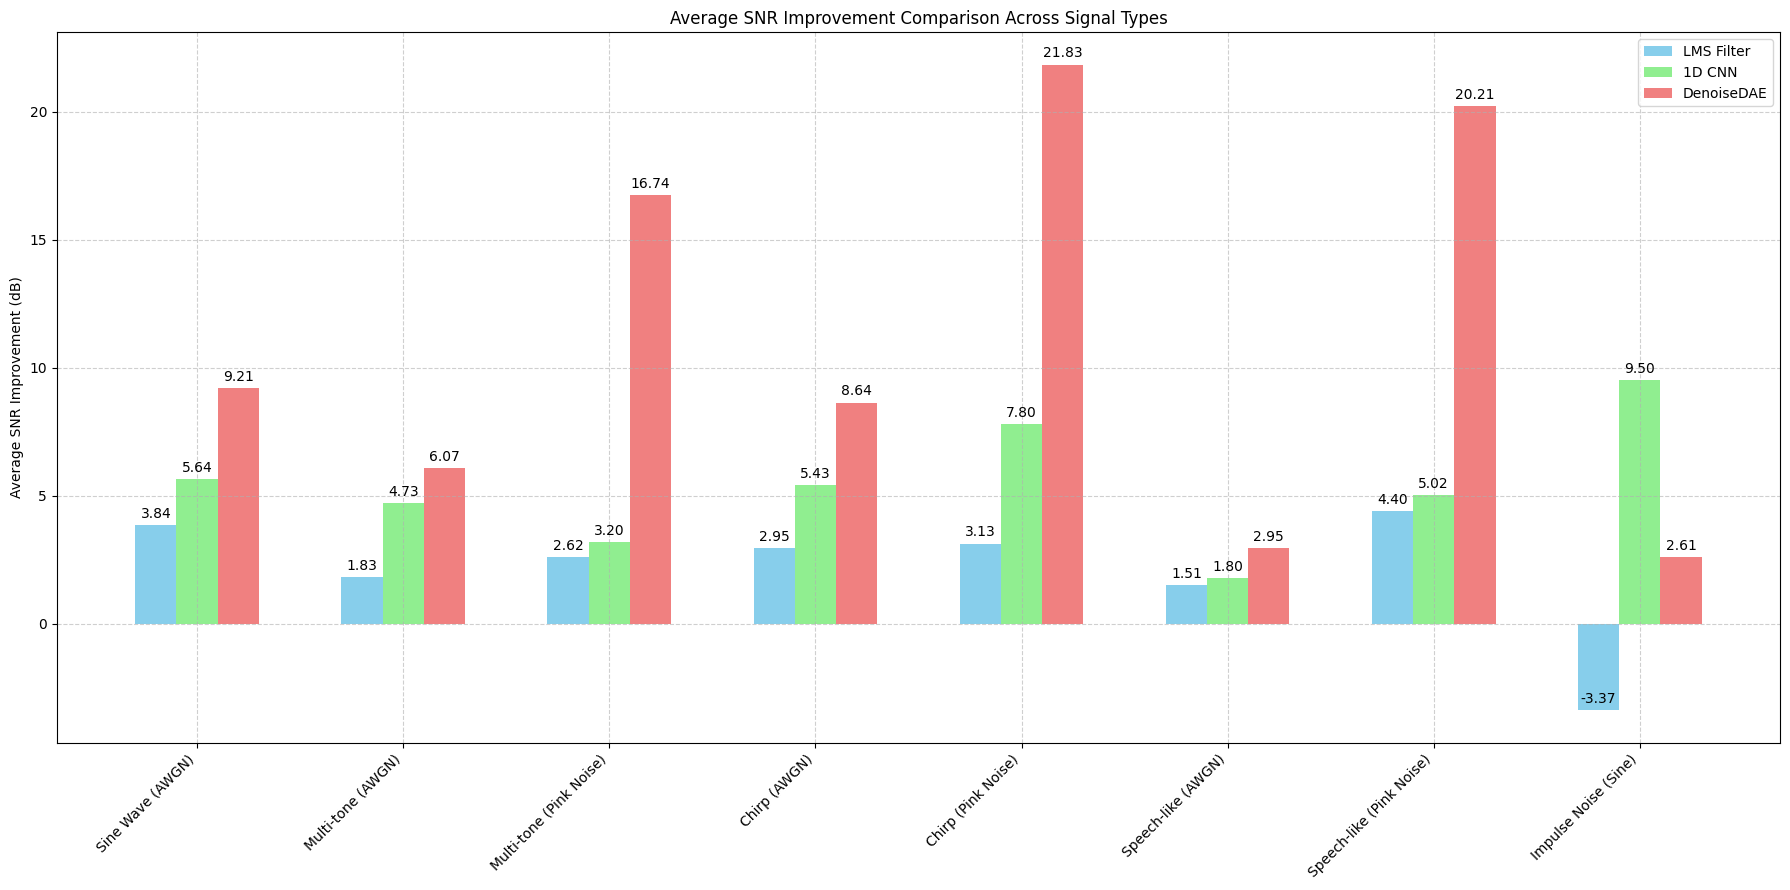

In [43]:
cnn_snr_improvement_data = {
    'Sine Wave (AWGN)': [],
    'Multi-tone (AWGN)': [],
    'Multi-tone (Pink Noise)': [],
    'Chirp (AWGN)': [],
    'Chirp (Pink Noise)': [],
    'Speech-like (AWGN)': [],
    'Speech-like (Pink Noise)': [],
    'Impulse Noise (Sine)': []
}

model.eval()
with torch.no_grad():
    for i in range(len(X_test_tensor)):
        clean_sample = y_test_np[i]
        noisy_sample = X_test_tensor[i].squeeze().numpy()
        current_signal_type = signal_types_test_np[i]

        # --- 1D CNN Denoising ---
        noisy_sample_tensor_cnn = X_test_tensor[i].unsqueeze(0)
        denoised_sample_tensor_cnn = model(noisy_sample_tensor_cnn)
        denoised_sample_cnn = denoised_sample_tensor_cnn.squeeze().numpy()
        snr_noisy_cnn_current = calculate_snr(clean_sample, noisy_sample)
        snr_cnn_current = calculate_snr(clean_sample, denoised_sample_cnn)

        snr_improvement_cnn = snr_cnn_current - snr_noisy_cnn_current

        if current_signal_type not in cnn_snr_improvement_data:
            cnn_snr_improvement_data[current_signal_type] = []
        cnn_snr_improvement_data[current_signal_type].append(snr_improvement_cnn)

avg_cnn_snr_imp_list_per_type = [np.mean(cnn_snr_improvement_data[s_type]) if cnn_snr_improvement_data[s_type] else 0 for s_type in signal_types]

x = np.arange(len(signal_types))
width = 0.2

fig, ax = plt.subplots(figsize=(18, 9))

rects1 = ax.bar(x - width, avg_lms_snr_imp_list, width, label='LMS Filter', color='skyblue')
rects2 = ax.bar(x, avg_cnn_snr_imp_list_per_type, width, label='1D CNN', color='lightgreen')
rects3 = ax.bar(x + width, avg_dae_snr_imp_list, width, label='DenoiseDAE', color='lightcoral')

ax.set_ylabel('Average SNR Improvement (dB)')
ax.set_title('Average SNR Improvement Comparison Across Signal Types')
ax.set_xticks(x)
ax.set_xticklabels(signal_types, rotation=45, ha="right")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.show()

### Average RMSE Comparison Across Signal Types (LMS vs. 1D CNN vs. DenoiseDAE)

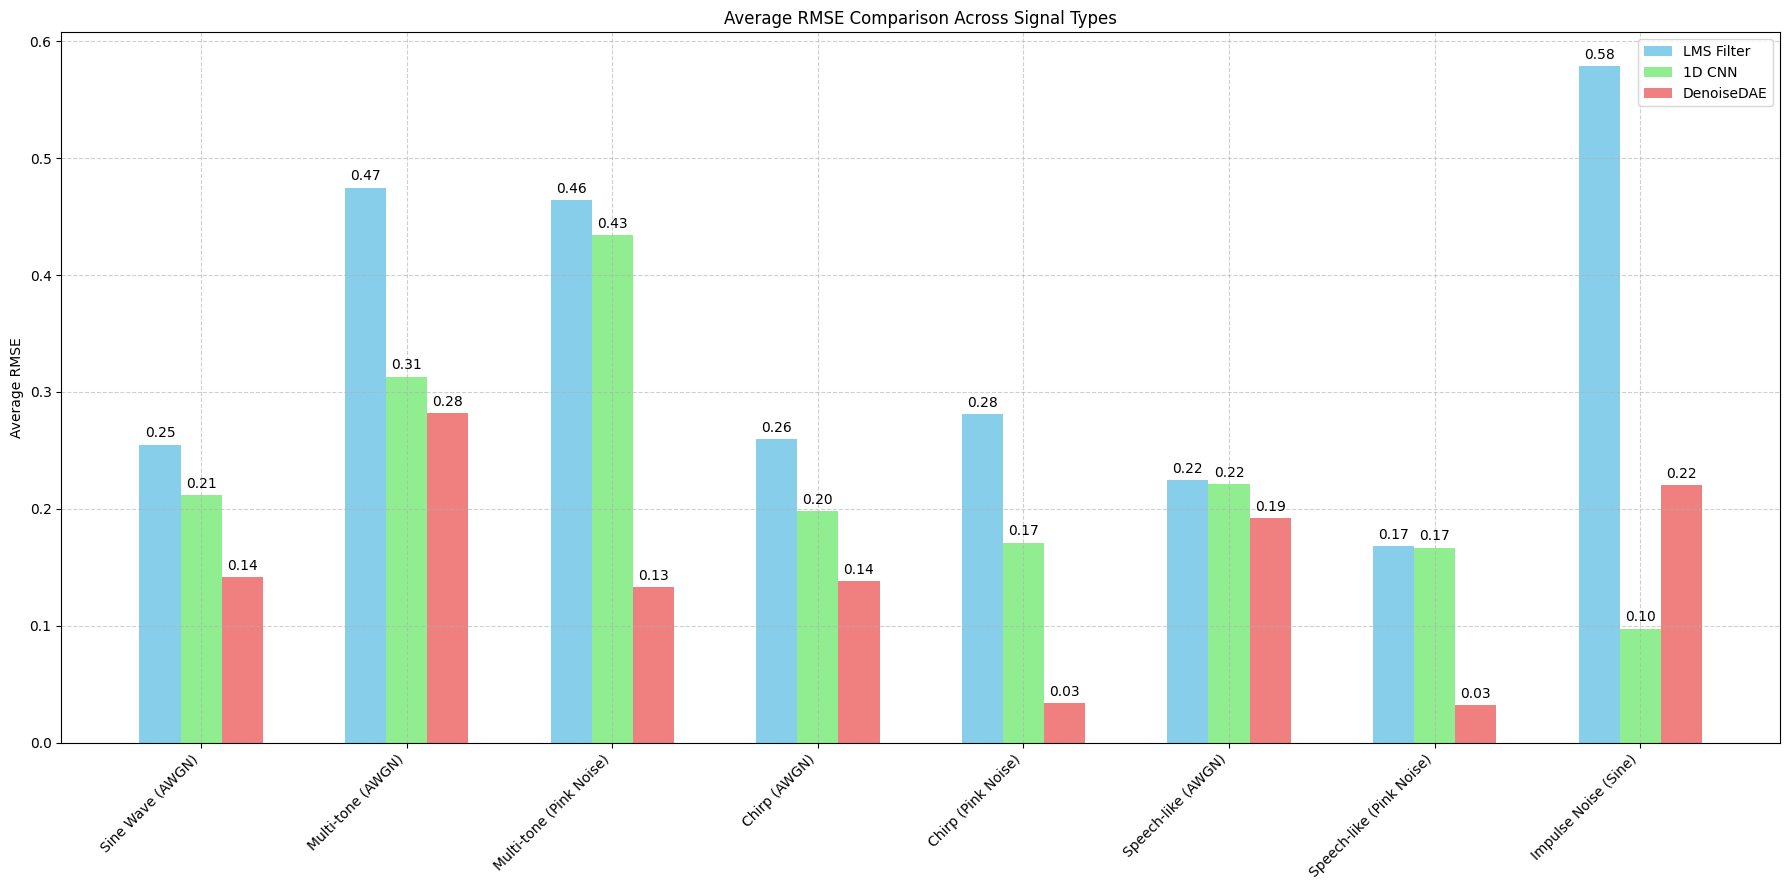

In [44]:
cnn_rmse_data = {
    'Sine Wave (AWGN)': [],
    'Multi-tone (AWGN)': [],
    'Multi-tone (Pink Noise)': [],
    'Chirp (AWGN)': [],
    'Chirp (Pink Noise)': [],
    'Speech-like (AWGN)': [],
    'Speech-like (Pink Noise)': [],
    'Impulse Noise (Sine)': []
}

model.eval()

with torch.no_grad():
    for i in range(len(X_test_tensor)):
        clean_sample = y_test_np[i]
        noisy_sample = X_test_tensor[i].squeeze().numpy()
        current_signal_type = signal_types_test_np[i]

        # --- 1D CNN Denoising ---
        noisy_sample_tensor_cnn = X_test_tensor[i].unsqueeze(0)
        denoised_sample_tensor_cnn = model(noisy_sample_tensor_cnn)
        denoised_sample_cnn = denoised_sample_tensor_cnn.squeeze().numpy()

        # Calculate RMSE for CNN
        rmse_cnn = calculate_rmse(clean_sample, denoised_sample_cnn)

        if current_signal_type not in cnn_rmse_data:
            cnn_rmse_data[current_signal_type] = []
        cnn_rmse_data[current_signal_type].append(rmse_cnn)


avg_cnn_rmse_list_per_type = [np.mean(cnn_rmse_data[s_type]) if cnn_rmse_data[s_type] else 0 for s_type in signal_types]

x = np.arange(len(signal_types))
width = 0.2

fig, ax = plt.subplots(figsize=(18, 9))

rects1 = ax.bar(x - width, avg_lms_rmse_list, width, label='LMS Filter', color='skyblue')
rects2 = ax.bar(x, avg_cnn_rmse_list_per_type, width, label='1D CNN', color='lightgreen')
rects3 = ax.bar(x + width, avg_dae_rmse_list, width, label='DenoiseDAE', color='lightcoral')

ax.set_ylabel('Average RMSE')
ax.set_title('Average RMSE Comparison Across Signal Types')
ax.set_xticks(x)
ax.set_xticklabels(signal_types, rotation=45, ha="right")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.show()

### Performance Metrics by Signal/Noise Type: LMS vs. 1D CNN vs. DenoiseDAE

| Signal Type                  | LMS RMSE | 1D CNN RMSE | DenoiseDAE RMSE | LMS SNR Imp. (dB) | 1D CNN SNR Imp. (dB) | DenoiseDAE SNR Imp. (dB) |
|:-----------------------------|:---------|:------------|:----------------|:------------------|:---------------------|:-------------------------|
| Sine Wave (AWGN)             | 0.31     | 0.24        | 0.17            | 3.47              | 5.59                 | 8.93                     |
| Multi-tone (AWGN)            | 0.46     | 0.33        | 0.29            | 2.03              | 4.62                 | 5.89                     |
| Multi-tone (Pink Noise)      | 0.43     | 0.41        | 0.07            | 2.40              | 3.03                 | 18.90                    |
| Chirp (AWGN)                 | 0.31     | 0.25        | 0.18            | 3.29              | 5.29                 | 8.58                     |
| Chirp (Pink Noise)           | 0.27     | 0.23        | 0.05            | 3.10              | 5.13                 | 18.63                    |
| Speech-like (AWGN)           | 0.23     | 0.23        | 0.19            | 1.55              | 1.61                 | 3.18                     |
| Speech-like (Pink Noise)     | 0.15     | 0.18        | 0.03            | 6.04              | 4.64                 | 19.18                    |
| Impulse Noise (Sine)         | 0.40     | 0.09        | 0.04            | -2.00             | 8.88                 | 15.23                    |